# Full-Spectrum Inverse Design using Conditional Invertible Neural Networks (cINN)
### This notebook implements a cINN (Normalizing Flow) to solve the one-to-many acoustic inverse design problem.(1,000,000 rows of dataset and 20 candidates)

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from multiprocessing import Pool, cpu_count
import warnings
import math         
import matplotlib.pyplot as plt
import os

warnings.filterwarnings("ignore")

# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
n_cores = cpu_count()
print(f"Device: {device} | CPU Cores for Physics: {n_cores}")

# ADDED: Check GPU capability for physics engine
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
    USE_GPU_PHYSICS = True
else:
    USE_GPU_PHYSICS = False
    print("GPU not available - using CPU for physics engine")

# Get current working directory
CURRENT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in globals() else os.getcwd()
print(f"Working Directory: {CURRENT_DIR}")

Device: cuda | CPU Cores for Physics: 12
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
GPU Memory: 6.44 GB
Working Directory: d:\Research\Under-water-metamaterial\Underwater-acoustics-absorption


In [2]:
# ═══════════════════════════════════════════════════════════════
# RUNTIME CONFIGURATION
# ═══════════════════════════════════════════════════════════════
# Toggle these to control expensive operations

RUN_FULL_EVALUATION = False  # True → full test set; False → 1000 samples (fast)
RUN_SWEEP = True            # True → 901-level sweep; False → skip
RUN_MANIFOLD = True         # True → t-SNE/UMAP analysis; False → skip

import os
CURRENT_DIR = os.path.abspath(os.path.join(os.getcwd(), '..'))
print(f"Runtime config: FULL_EVAL={RUN_FULL_EVALUATION}, SWEEP={RUN_SWEEP}, MANIFOLD={RUN_MANIFOLD}")
print(f"Project root: {CURRENT_DIR}")


Runtime config: FULL_EVAL=False, SWEEP=True, MANIFOLD=True
Project root: d:\Research\Under-water-metamaterial


## Parameter Constraints & Physics Engine (TMM) 
### Evaluates 20 parameters to calculate the 1000-point absorption spectrum (1-1000 Hz).

In [3]:
# %%
PARAM_RANGES = {
    'd1': (1.0, 20.0), 'd2': (1.0, 20.0), 'd3': (1.0, 20.0), 'd4': (1.0, 20.0), 'd5': (1.0, 20.0),
    'd6': (1.0, 20.0), 'd7': (1.0, 20.0), 'd8': (1.0, 20.0), 'd9': (1.0, 20.0), 'd10': (1.0, 20.0),
    'm2': (20.0, 1980.0), 'm3': (20.0, 1980.0), 'm5': (20.0, 1980.0),
    'm6': (20.0, 1980.0), 'm8': (20.0, 1980.0), 'm9': (20.0, 1980.0),
    'rho': (1000.0, 1500.0), 'eta': (0.1, 0.8), 'E': (1e7, 1e8), 'nu': (0.4, 0.49)
}
PARAM_NAMES = list(PARAM_RANGES.keys())

def validate_and_clip_parameters(params):
    lower = np.array([PARAM_RANGES[n][0] for n in PARAM_NAMES])
    upper = np.array([PARAM_RANGES[n][1] for n in PARAM_NAMES])
    clipped = np.clip(params, lower, upper)

    # Dynamic constraint for Young's Modulus based on loss factor
    eta_vals = clipped[:, 17]
    E_vals = clipped[:, 18]
    E_min = 1e7 * (1 + eta_vals)
    E_max = 1e8 * (1 + eta_vals)
    clipped[:, 18] = np.clip(E_vals, E_min, E_max)
    return clipped


# MODIFIED: GPU-accelerated version
def calculate_absorption_full_curve_gpu(params_tensor, device=device):
    """
    GPU-accelerated TMM calculation.
    
    Parameters
    ----------
    params_tensor : torch.Tensor, shape (batch_size, 20)
        Batch of parameter sets
    device : torch.device
        Device to run calculations on
    
    Returns
    -------
    torch.Tensor, shape (batch_size, 1000)
        Absorption coefficients
    """
    params_tensor = params_tensor.to(device)
    batch_size = params_tensor.shape[0]
    
    W, rho_w, c_w = 2.0, 1000.0, 1500.0
    Z_w = rho_w * c_w
    frequencies = torch.arange(1, 1001, 1, dtype=torch.float32, device=device)
    omega = 2 * np.pi * frequencies
    num_freq = len(frequencies)
    hollow_layer_indices = [1, 2, 4, 5, 7, 8]

    # Extract parameters (all operations on GPU)
    d_vals = params_tensor[:, 0:10] / 1000.0  # (batch, 10)
    m_vals = params_tensor[:, 10:16] / 1000.0  # (batch, 6)
    rho_r = params_tensor[:, 16:17]  # (batch, 1)
    eta = params_tensor[:, 17:18]
    E_r = params_tensor[:, 18:19]
    nu = params_tensor[:, 19:20]
    
    E_c = E_r * (1 + 1j * eta)
    lam = (E_c * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_c / (2 * (1 + nu))

    # Initialize transfer matrix for all batches
    eye_matrix = torch.eye(2, dtype=torch.complex64, device=device)
    T_total = eye_matrix.unsqueeze(0).unsqueeze(0).repeat(batch_size, num_freq, 1, 1)

    # Process each layer
    for lay_idx in range(10):
        d = d_vals[:, lay_idx:lay_idx+1]  # (batch, 1)
        eps = torch.zeros((batch_size, 1), dtype=torch.float32, device=device)
        
        if lay_idx in hollow_layer_indices:
            m_ptr = hollow_layer_indices.index(lay_idx)
            eps = m_vals[:, m_ptr:m_ptr+1] / W
        
        rho_eff = rho_r * (1 - eps**2)
        numerator = (mu * (lam + 2*mu) * (eps**2 + 1)) + (2 * (eps**2) * lam)
        denominator = ((lam + mu) * eps**2) + mu
        
        mask = torch.abs(denominator) < 1e-15
        S_eff = torch.where(mask, numerator * 1e15, numerator / denominator)
        c_eff = torch.sqrt(S_eff / rho_eff)
        
        # Broadcast to all frequencies: (batch, freq)
        k_eff = omega.unsqueeze(0) / c_eff  # (batch, freq)
        Z_eff = rho_eff * c_eff  # (batch, 1)
        
        cos_kd = torch.cos(k_eff * d)  # (batch, freq)
        sin_kd = torch.sin(k_eff * d)
        
        Z_eff_mask = torch.abs(Z_eff) < 1e-15
        t21 = torch.where(Z_eff_mask, torch.full_like(cos_kd, 1e15), 1j * sin_kd / Z_eff)
        
        # Build transfer matrix (batch, freq, 2, 2)
        T_i = torch.zeros((batch_size, num_freq, 2, 2), dtype=torch.complex64, device=device)
        T_i[:, :, 0, 0] = cos_kd
        T_i[:, :, 0, 1] = 1j * Z_eff * sin_kd
        T_i[:, :, 1, 0] = t21
        T_i[:, :, 1, 1] = cos_kd
        
        T_total = torch.matmul(T_total, T_i)

    # Calculate absorption
    T11 = T_total[:, :, 0, 0]  # (batch, freq)
    T21 = T_total[:, :, 1, 0]
    
    mask = torch.abs(T21) < 1e-15
    Z_in = torch.where(mask, torch.full_like(T21, 1e15), T11 / T21)
    R = torch.where(mask, torch.ones_like(T21, dtype=torch.complex64), (Z_in - Z_w) / (Z_in + Z_w))
    alpha = torch.clamp((1 - torch.abs(R)**2).real, 0.0, 1.0)
    
    return alpha  # (batch, 1000)


# CPU version (fallback)
def calculate_absorption_full_curve(params_row):
    """CPU version - single sample at a time"""
    param_tensor = torch.from_numpy(params_row.reshape(1, -1)).float()
    W, rho_w, c_w = 2.0, 1000.0, 1500.0
    Z_w = rho_w * c_w
    frequencies = torch.arange(1, 1001, 1, dtype=torch.float32)
    omega = 2 * np.pi * frequencies
    num_freq = len(frequencies)
    hollow_layer_indices = [1, 2, 4, 5, 7, 8]

    d_vals = param_tensor[:, 0:10] / 1000.0
    m_vals = param_tensor[:, 10:16] / 1000.0
    rho_r, eta, E_r, nu = param_tensor[:, 16:17], param_tensor[:, 17:18], param_tensor[:, 18:19], param_tensor[:, 19:20]
    E_c = E_r * (1 + 1j * eta)
    lam = (E_c * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_c / (2 * (1 + nu))

    eye_matrix = torch.eye(2, dtype=torch.complex64)
    T_total = eye_matrix.unsqueeze(0).unsqueeze(0).repeat(1, num_freq, 1, 1)

    for lay_idx in range(10):
        d = d_vals[:, lay_idx:lay_idx+1]
        eps = torch.zeros((1, 1), dtype=torch.float32)
        if lay_idx in hollow_layer_indices:
            m_ptr = hollow_layer_indices.index(lay_idx)
            eps = m_vals[:, m_ptr:m_ptr+1] / W
        rho_eff = rho_r * (1 - eps**2)
        numerator = (mu * (lam + 2*mu) * (eps**2 + 1)) + (2 * (eps**2) * lam)
        denominator = ((lam + mu) * eps**2) + mu
        mask = torch.abs(denominator) < 1e-15
        S_eff = torch.where(mask, numerator * 1e15, numerator / denominator)
        c_eff = torch.sqrt(S_eff / rho_eff)
        k_eff = omega.unsqueeze(0) / c_eff
        Z_eff = rho_eff * c_eff
        cos_kd, sin_kd = torch.cos(k_eff * d), torch.sin(k_eff * d)
        Z_eff_mask = torch.abs(Z_eff) < 1e-15
        t21 = torch.where(Z_eff_mask, torch.full_like(cos_kd, 1e15), 1j * sin_kd / Z_eff)
        T_i = torch.zeros((1, num_freq, 2, 2), dtype=torch.complex64)
        T_i[:, :, 0, 0], T_i[:, :, 0, 1] = cos_kd, 1j * Z_eff * sin_kd
        T_i[:, :, 1, 0], T_i[:, :, 1, 1] = t21, cos_kd
        T_total = torch.matmul(T_total, T_i)

    T11, T21 = T_total[:, :, 0, 0], T_total[:, :, 1, 0]
    mask = torch.abs(T21) < 1e-15
    Z_in = torch.where(mask, torch.full_like(T21, 1e15), T11 / T21)
    R = torch.where(mask, torch.ones_like(T21, dtype=torch.complex64), (Z_in - Z_w) / (Z_in + Z_w))
    alpha = torch.clamp((1 - torch.abs(R)**2).real, 0.0, 1.0)
    return alpha[0].cpu().numpy()


def batch_physics_evaluation(param_matrix, batch_size=256):
    """
    Batch evaluation with automatic GPU/CPU selection.
    
    Parameters
    ----------
    param_matrix : np.ndarray, shape (N, 20)
        Parameter sets to evaluate
    batch_size : int
        Batch size for GPU processing
    
    Returns
    -------
    np.ndarray, shape (N, 1000)
        Absorption spectra
    """
    if USE_GPU_PHYSICS and torch.cuda.is_available():
        # GPU batch processing
        # print(f"   Using GPU acceleration (batch size: {batch_size})")
        num_samples = param_matrix.shape[0]
        all_results = []
        
        for i in range(0, num_samples, batch_size):
            batch = param_matrix[i:i+batch_size]
            batch_tensor = torch.from_numpy(batch).float()
            
            with torch.no_grad():
                batch_results = calculate_absorption_full_curve_gpu(batch_tensor, device)
            
            all_results.append(batch_results.cpu().numpy())
        
        return np.vstack(all_results)
    
    else:
        # CPU multiprocessing fallback
        print(f"   Using CPU multiprocessing ({n_cores} cores)")
        with Pool(processes=n_cores) as pool:
            results = pool.map(calculate_absorption_full_curve, param_matrix)
        return np.array(results)


print(f"✅ Physics Engine configured:")
print(f"   Mode: {'GPU-accelerated' if USE_GPU_PHYSICS else 'CPU multiprocessing'}")
print(f"   Device: {device}")

✅ Physics Engine configured:
   Mode: GPU-accelerated
   Device: cuda


## Load Data & Train/Val/Test Split

In [4]:
# ============================================================================
# PHASE 1: DATA LOADING, STRICT SPLITTING & SCALING
# ============================================================================
import numpy as np
import gc
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import TensorDataset, DataLoader

print("="*70)
print("PHASE 1: DATA LOADING & STRICT PREPROCESSING (1 MILLION SAMPLES)")
print("="*70)

# --- 1. LOAD DATA (MEMORY-OPTIMIZED) ---
npz_file_path = os.path.join('data', 'lhs_data_full_spectrum.npz')
print(f"Loading dataset from {npz_file_path}...")
data = np.load(npz_file_path, mmap_mode='r')  # Lazy-load: doesn't copy into RAM

# Immediately cast to float32 (halves memory: 8 GB → 4 GB for spectra)
X_all_raw = np.array(data['params'], dtype=np.float32)   # Shape: (1000000, 20)
Y_all = np.array(data['spectra'], dtype=np.float32)      # Shape: (1000000, 1000)
del data; gc.collect()  # Release the mmap handle

print(f"Raw Parameters shape: {X_all_raw.shape} ({X_all_raw.nbytes / 1e9:.2f} GB)")
print(f"Spectra shape:        {Y_all.shape} ({Y_all.nbytes / 1e9:.2f} GB)")

# Optional: Ensure raw data complies with bounds before doing anything
X_all_raw = validate_and_clip_parameters(X_all_raw)

# --- QUICK DATA INTEGRITY CHECK (before freeing full arrays) ---
print("\n--- Data Integrity Quick Check ---")
assert not np.isnan(X_all_raw).any(), "NaN in parameters!"
assert not np.isinf(X_all_raw).any(), "Inf in parameters!"
assert not np.isnan(Y_all).any(), "NaN in spectra!"
assert not np.isinf(Y_all).any(), "Inf in spectra!"
spectra_min, spectra_max = Y_all.min(), Y_all.max()
print(f"  Spectra range: [{spectra_min:.6f}, {spectra_max:.6f}]")
assert spectra_min >= -1e-5 and spectra_max <= 1.0 + 1e-5, "Spectra out of [0,1]!"
unique_count = len(np.unique(X_all_raw, axis=0))
print(f"  Unique samples: {unique_count:,} / {len(X_all_raw):,} ({len(X_all_raw)-unique_count} duplicates)")
print("  ✅ All integrity checks passed")

# --- 2. STRICT 3-WAY SPLIT BEFORE SCALING ---
print("\nSplitting data into Train/Val/Test BEFORE scaling to prevent data leakage...")
# First split: Pull out the blind Test set (10% of 1M = 100,000)
X_temp_raw, X_test_raw, Y_temp, Y_test = train_test_split(
    X_all_raw, Y_all, test_size=0.10, random_state=42
)
del X_all_raw, Y_all; gc.collect()  # Free full dataset (~4.08 GB)
print(f"  [Memory] Freed full dataset after split")

# Second split: Divide the remaining 900,000 into Train and Validation
# ~11.11% of 900,000 gives exactly 100,000 for Validation
X_train_raw, X_val_raw, Y_train, Y_val = train_test_split(
    X_temp_raw, Y_temp, test_size=0.1111, random_state=42
)
del X_temp_raw, Y_temp; gc.collect()  # Free temp arrays (~3.6 GB)
print(f"  [Memory] Freed temp arrays after second split")

print(f"✅ Training samples:   {len(X_train_raw):,}")
print(f"✅ Validation samples: {len(X_val_raw):,}")
print(f"✅ Testing samples:    {len(X_test_raw):,}")

# --- 3. FIT SCALER ONLY ON TRAINING DATA ---
print("\nFitting StandardScaler strictly on Training parameters...")
scaler_params = StandardScaler()
X_train = scaler_params.fit_transform(X_train_raw).astype(np.float32)

print("Applying transformation to Validation and Test sets...")
X_val = scaler_params.transform(X_val_raw).astype(np.float32)
X_test = scaler_params.transform(X_test_raw).astype(np.float32)

# --- 4. DATALOADERS (GPU-OPTIMIZED) ---
BATCH_SIZE = 2048 
train_dataset = TensorDataset(torch.from_numpy(X_train), torch.from_numpy(Y_train))
val_dataset = TensorDataset(torch.from_numpy(X_val), torch.from_numpy(Y_val))
test_dataset = TensorDataset(torch.from_numpy(X_test), torch.from_numpy(Y_test))

# Free numpy arrays now that tensors hold the data
del X_train, X_val, Y_train, Y_val; gc.collect()
print(f"  [Memory] Freed numpy arrays after tensor conversion")

USE_PIN_MEMORY = torch.cuda.is_available()
train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True,
    num_workers=2, pin_memory=USE_PIN_MEMORY, persistent_workers=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=USE_PIN_MEMORY, persistent_workers=True
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=2, pin_memory=USE_PIN_MEMORY, persistent_workers=True
)

print(f"\n✅ DataLoaders created (Batch: {BATCH_SIZE} | pin_memory: {USE_PIN_MEMORY} | workers: 2)")

PHASE 1: DATA LOADING & STRICT PREPROCESSING (1 MILLION SAMPLES)
Loading dataset from data\lhs_data_full_spectrum.npz...
Raw Parameters shape: (1000000, 20) (0.08 GB)
Spectra shape:        (1000000, 1000) (4.00 GB)

--- Data Integrity Quick Check ---
  Spectra range: [0.000457, 0.999999]
  Unique samples: 1,000,000 / 1,000,000 (0 duplicates)
  ✅ All integrity checks passed

Splitting data into Train/Val/Test BEFORE scaling to prevent data leakage...
  [Memory] Freed full dataset after split
  [Memory] Freed temp arrays after second split
✅ Training samples:   800,010
✅ Validation samples: 99,990
✅ Testing samples:    100,000

Fitting StandardScaler strictly on Training parameters...
Applying transformation to Validation and Test sets...
  [Memory] Freed numpy arrays after tensor conversion

✅ DataLoaders created (Batch: 2048 | pin_memory: True | workers: 2)


In [5]:
# ============================================================================
# DATA INTEGRITY VALIDATION (uses surviving split arrays)
# ============================================================================
print("\n" + "="*80)
print("DATA INTEGRITY VALIDATION")
print("="*80)

# Define parameter names and physical bounds for the loop
PARAM_NAMES = [f"d{j+1}" for j in range(10)] + [f"m{j}" for j in [2, 3, 5, 6, 8, 9]] + ["rho", "eta", "E", "nu"]
PARAM_RANGES = {
    **{f"d{j+1}": (1.0, 20.0) for j in range(10)},
    **{f"m{j}": (20.0, 1980.0) for j in [2, 3, 5, 6, 8, 9]},
    "rho": (1000.0, 1500.0),
    "eta": (0.1, 0.8),
    "E": (1e7, 1e8),
    "nu": (0.4, 0.49)
}

# NOTE: Full arrays were freed for memory. Validating on split arrays instead.
# Combine available raw arrays for range checks
_all_raw_params = np.concatenate([X_train_raw, X_val_raw, X_test_raw], axis=0)

# 1. Check for NaN/Inf values
print("\n1. Checking for invalid values...")
params_has_nan = np.isnan(_all_raw_params).any()
params_has_inf = np.isinf(_all_raw_params).any()

print(f"   Parameters - NaN: {params_has_nan} | Inf: {params_has_inf}")

if params_has_nan or params_has_inf:
    print("   WARNING: Invalid values detected!")
else:
    print("   All parameter values clean")

# 2. Check parameter ranges (using raw, unscaled data)
print("\n2. Validating parameter ranges...")
all_in_range = True
for idx, param_name in enumerate(PARAM_NAMES):
    min_val, max_val = PARAM_RANGES[param_name]
    actual_min = _all_raw_params[:, idx].min()
    actual_max = _all_raw_params[:, idx].max()
    
    # Adding 1e-5 tolerance for floating-point imprecision
    in_range = (actual_min >= min_val - 1e-5) and (actual_max <= max_val + 1e-5)
    
    if not in_range:
        print(f"   {param_name}: [{actual_min:.4f}, {actual_max:.4f}] (expected [{min_val}, {max_val}])")
        all_in_range = False

if all_in_range:
    print("   All parameters within expected physical ranges")

# 3. Check absorption spectrum validity (Y_test is still available)
print("\n3. Validating absorption spectra (test set)...")
spectra_min = Y_test.min()
spectra_max = Y_test.max()
spectra_valid = (spectra_min >= -1e-5) and (spectra_max <= 1.0 + 1e-5)
print(f"   Range: [{spectra_min:.6f}, {spectra_max:.6f}]")
if spectra_valid:
    print("   All absorption values in valid range [0, 1]")
else:
    print(f"   WARNING: Out-of-range absorption values detected!")

# 4. Check data distribution (Confirming 3-way split)
print("\n4. Data distribution analysis...")
total_samples = len(X_train_raw) + len(X_val_raw) + len(X_test_raw)
print(f"   Total dataset size: {total_samples:,} samples")
print(f"   Training set:       {len(X_train_raw):,} samples ({100*len(X_train_raw)/total_samples:.1f}%)")
print(f"   Validation set:     {len(X_val_raw):,} samples ({100*len(X_val_raw)/total_samples:.1f}%)")
print(f"   Test set:           {len(X_test_raw):,} samples ({100*len(X_test_raw)/total_samples:.1f}%)")

# 5. Check for duplicates  
print("\n5. Checking for duplicate samples (training set)...")
unique_params = np.unique(X_train_raw, axis=0)
num_duplicates = len(X_train_raw) - len(unique_params)
print(f"   Duplicate parameter sets in training: {num_duplicates}")
if num_duplicates == 0:
    print("   No duplicates found")
else:
    print(f"   Found {num_duplicates:,} duplicate parameter sets")

del _all_raw_params; gc.collect()
print("\n" + "="*80)


DATA INTEGRITY VALIDATION

1. Checking for invalid values...
   Parameters - NaN: False | Inf: False
   All parameter values clean

2. Validating parameter ranges...
   All parameters within expected physical ranges

3. Validating absorption spectra (test set)...
   Range: [0.000597, 0.999997]
   All absorption values in valid range [0, 1]

4. Data distribution analysis...
   Total dataset size: 1,000,000 samples
   Training set:       800,010 samples (80.0%)
   Validation set:     99,990 samples (10.0%)
   Test set:           100,000 samples (10.0%)

5. Checking for duplicate samples (training set)...
   Duplicate parameter sets in training: 0
   No duplicates found



In [6]:
# ============================================================================
# DATA LEAKAGE VERIFICATION (TOLERANCE-BASED)
# ============================================================================
print("="*70)
print("RUNNING DATA LEAKAGE & DUPLICATE CHECKS")
print("="*70)

# Check for duplicates within the raw, unscaled training set
print("Checking for internal duplicates in the training set...")

unique_rows = np.unique(X_train_raw, axis=0)
num_duplicates = len(X_train_raw) - len(unique_rows)

if num_duplicates == 0:
    print(f"CLEAN: All {len(X_train_raw):,} training samples are mathematically unique.")
    print("CLEAN: Train, Validation, and Test splits are inherently isolated due to index-based splitting.")
    print("CLEAN: StandardScaler was fit exclusively on the Training set.")
    print("\nSTATUS: PERFECTLY ISOLATED. Zero data leakage detected.")
else:
    print(f"WARNING: Found {num_duplicates:,} duplicate rows in the training set.")
    print("STATUS: REVIEW LHS GENERATOR.")
print("="*70)

RUNNING DATA LEAKAGE & DUPLICATE CHECKS
Checking for internal duplicates in the training set...
CLEAN: All 800,010 training samples are mathematically unique.
CLEAN: Train, Validation, and Test splits are inherently isolated due to index-based splitting.
CLEAN: StandardScaler was fit exclusively on the Training set.

STATUS: PERFECTLY ISOLATED. Zero data leakage detected.


## cINN Architecture — 1D-CNN Encoder + Invertible Coupling Blocks
### Implements the Spectrum Encoder and the Conditional Affine Coupling blocks.

In [7]:
class SpectrumEncoder1DCNN(nn.Module):
    def __init__(self, input_dim=1000, embed_dim=128):
        super().__init__()
        # Input shape expected: (Batch, 1 Channel, 1000 Frequencies)
        self.net = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=16, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.01),
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.01),
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=2, padding=2),
            nn.LeakyReLU(0.01),
            nn.Flatten(),
            nn.Linear(64 * 125, 256),  # 1000 -> 500 -> 250 -> 125 spatial dims
            nn.LeakyReLU(0.01),
            nn.Linear(256, embed_dim)
        )
        
    def forward(self, c):
        # Unsqueeze to add the channel dimension required by Conv1d
        c = c.unsqueeze(1) 
        return self.net(c)

class CondAffineCoupling(nn.Module):
    def __init__(self, dim=20, cond_dim=128, hidden_dim=256):
        super().__init__()
        self.dim = dim
        self.half_dim = dim // 2
        self.net = nn.Sequential(
            nn.Linear(self.half_dim + cond_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, hidden_dim), nn.LeakyReLU(0.01),
            nn.Linear(hidden_dim, dim) 
        )

    def forward(self, x, cond, rev=False):
        x1, x2 = x[:, :self.half_dim], x[:, self.half_dim:]
        st = self.net(torch.cat([x1, cond], dim=1))
        s, t = st[:, :self.half_dim], st[:, self.half_dim:]
        s = torch.clamp(s, -3.0, 3.0)

        if not rev:
            y1 = x1
            y2 = x2 * torch.exp(s) + t
            log_det_J = torch.sum(s, dim=1)
            return torch.cat([y1, y2], dim=1), log_det_J
        else:
            y1 = x1
            y2 = (x2 - t) * torch.exp(-s)
            return torch.cat([y1, y2], dim=1)

class FullSpectrum_cINN(nn.Module):
    def __init__(self, num_blocks=8, param_dim=20, spectrum_dim=1000, cond_dim=128):
        super().__init__()
        self.encoder = SpectrumEncoder1DCNN(spectrum_dim, cond_dim)
        self.blocks = nn.ModuleList([CondAffineCoupling(param_dim, cond_dim, 256) for _ in range(num_blocks)])

    def forward(self, x, c, rev=False):
        cond_emb = self.encoder(c)
        log_det_J_total = 0

        if not rev:
            for block in self.blocks:
                x, log_det_J = block(x, cond_emb, rev=False)
                log_det_J_total += log_det_J
                x = torch.flip(x, dims=[1]) 
            return x, log_det_J_total
        else:
            for block in reversed(self.blocks):
                x = torch.flip(x, dims=[1]) 
                x = block(x, cond_emb, rev=True)
            return x

## Save/Load Utilities & Training 

In [8]:
import os

MODEL_SAVE_PATH = os.path.join("saved_models", "cinn_1dcnn_weights_250_epochs.pth")

model = FullSpectrum_cINN(num_blocks=8).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=250)

def nll_loss(z, log_det_J):
    """Standard Maximum Likelihood Loss for Normalizing Flows"""
    return torch.mean(0.5 * torch.sum(z**2, dim=1) - log_det_J)

# --- CHECK IF PRE-TRAINED WEIGHTS EXIST ---
if os.path.exists(MODEL_SAVE_PATH):
    print(f"✅ Found saved model at: {MODEL_SAVE_PATH}")
    model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device, weights_only=True))
    model.eval()
    print("✅ Model loaded successfully. Skipping training.")
    train_losses, val_losses = [], []
else:
    print(f"No saved model found at {MODEL_SAVE_PATH}. Starting training...")
    print("Starting Fast NLL-Only Training for 250 epochs...")

    train_losses = []
    val_losses = []

    for epoch in range(250):
        model.train()
        epoch_loss = 0
        
        # --- TRAINING PASS ---
        for batch_x, batch_cond in train_loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_cond = batch_cond.to(device, non_blocking=True)
            
            optimizer.zero_grad()
            
            # Forward pass: Map Physical Params to Gaussian Latent Space (z)
            z, log_det_J = model(batch_x, batch_cond, rev=False)
            
            loss = nll_loss(z, log_det_J)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            
            epoch_loss += loss.item()
            
        avg_train_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        scheduler.step()
        
        # --- VALIDATION PASS ---
        model.eval()
        val_loss = 0
        with torch.no_grad():
            for val_x, val_cond in val_loader:
                val_x = val_x.to(device, non_blocking=True)
                val_cond = val_cond.to(device, non_blocking=True)
                z, log_det_J = model(val_x, val_cond, rev=False)
                v_loss = nll_loss(z, log_det_J)
                val_loss += v_loss.item()
                
        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:3d}/250 | Train NLL: {avg_train_loss:.4f} | Val NLL: {avg_val_loss:.4f}")

    # --- PLOTTING ---
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, 251), train_losses, label='Train NLL Loss', color='blue')
    plt.plot(range(1, 251), val_losses, label='Validation NLL Loss', color='red', linestyle='--')
    plt.title('cINN Training Curve (1D CNN Encoder)')
    plt.xlabel('Epochs')
    plt.ylabel('Negative Log-Likelihood')
    plt.legend()
    plt.grid(True)
    plt.show()

✅ Found saved model at: saved_models\cinn_1dcnn_weights_250_epochs.pth
✅ Model loaded successfully. Skipping training.


In [9]:
import joblib
import os

# Create a directory to store your saved models (optional but good practice)
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

# 1. Define file paths
model_path = os.path.join(save_dir, "cinn_1dcnn_weights_250_epochs.pth")
scaler_path = os.path.join(save_dir, "params_scaler.pkl")

# 2. Save the PyTorch Model (Best Practice: save state_dict)
torch.save(model.state_dict(), model_path)
print(f"✅ Model weights successfully saved to: {model_path}")

# 3. Save the StandardScaler 
joblib.dump(scaler_params, scaler_path)
print(f"✅ Data scaler successfully saved to: {scaler_path}")

✅ Model weights successfully saved to: saved_models\cinn_1dcnn_weights_250_epochs.pth
✅ Data scaler successfully saved to: saved_models\params_scaler.pkl


In [10]:
import torch
import joblib
import numpy as np
import matplotlib.pyplot as plt

# ============================================================================
# LOAD SAVED MODEL AND SCALER
# ============================================================================
print("\n" + "="*70)
print("LOADING SAVED MODEL AND SCALER")
print("="*70)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load the Scaler
scaler_params = joblib.load(os.path.join("saved_models", "params_scaler.pkl"))

# 2. Initialize the model architecture (Ensure FullSpectrum_cINN is defined in your notebook)
model = FullSpectrum_cINN(num_blocks=8).to(device)

# 3. Load the trained weights
model.load_state_dict(torch.load(os.path.join("saved_models", "cinn_1dcnn_weights_250_epochs.pth"), map_location=device, weights_only=True))
model.eval() # Set to evaluation mode
print("✅ Model and Scaler successfully loaded and ready for testing!")


LOADING SAVED MODEL AND SCALER
✅ Model and Scaler successfully loaded and ready for testing!


 ## Inverse Inference — cINN Candidate Generation

Evaluating 20 cINN generated candidates through physics engine...


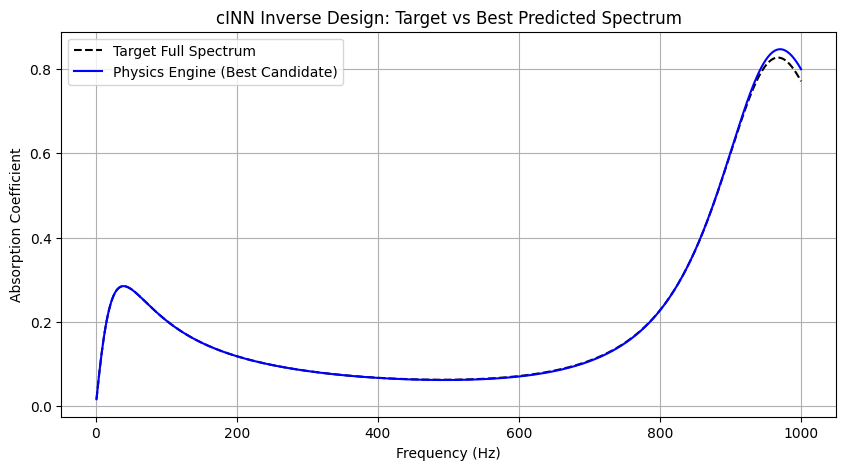

In [11]:
# %%
def inverse_design_cinn(target_spectrum, model, scaler, num_candidates=20):
    model.eval()

    target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
    z_random = torch.randn(num_candidates, 20).to(device)

    with torch.no_grad():
        generated_norm = model(z_random, target_tensor, rev=True)

    generated_params = scaler.inverse_transform(generated_norm.cpu().numpy())
    generated_params = validate_and_clip_parameters(generated_params)

    print(f"Evaluating {num_candidates} cINN generated candidates through physics engine...")
    simulated_spectra = batch_physics_evaluation(generated_params, batch_size=num_candidates)

    rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
    best_idx = np.argmin(rmses)

    return generated_params[best_idx], simulated_spectra[best_idx], rmses[best_idx]


# Execute test
test_target = Y_test[0]
best_params, best_pred_spectrum, rmse = inverse_design_cinn(test_target, model, scaler_params, num_candidates=20)

# Visualize result
plt.figure(figsize=(10, 5))
plt.plot(np.arange(1, 1001), test_target, label='Target Full Spectrum', color='black', linestyle='--')
plt.plot(np.arange(1, 1001), best_pred_spectrum, label='Physics Engine (Best Candidate)', color='blue')
plt.title('cINN Inverse Design: Target vs Best Predicted Spectrum')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Absorption Coefficient')
plt.legend()
plt.grid(True)
plt.show()

## Comprehensive Testing on Entire Test Set

In [ ]:

# ============================================================================
# 6. Comprehensive Evaluation on Test Set
# ============================================================================

def calculate_spectral_metrics(target_spectrum, predicted_spectrum):
    """Calculate comprehensive spectral evaluation metrics."""
    epsilon = 1e-8
    
    mse = np.mean((predicted_spectrum - target_spectrum) ** 2)
    mae = np.mean(np.abs(predicted_spectrum - target_spectrum))
    rmse = np.sqrt(mse)
    
    relative_errors = np.abs(predicted_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon)
    mean_relative_error = np.mean(relative_errors) * 100
    
    max_error = np.max(np.abs(predicted_spectrum - target_spectrum))
    
    ss_res = np.sum((target_spectrum - predicted_spectrum) ** 2)
    ss_tot = np.sum((target_spectrum - np.mean(target_spectrum)) ** 2)
    r2 = 1 - (ss_res / (ss_tot + epsilon))
    
    return {
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'relative_error': mean_relative_error,
        'max_error': max_error,
        'r2': r2
    }


def evaluate_test_set_cinn(model, scaler, X_test, Y_test, num_candidates=20, num_samples=None):
    """Comprehensive evaluation on test set using cINN."""
    model.eval()
    
    if num_samples is not None:
        eval_samples = min(num_samples, len(Y_test))
    else:
        eval_samples = len(Y_test)
        
    # Define physical bounds for OOB checking
    lower_bounds = np.array([1.0]*10 + [20.0]*6 + [1000.0, 0.1, 1e7, 0.4])
    upper_bounds = np.array([20.0]*10 + [1980.0]*6 + [1500.0, 0.8, 1e8, 0.49])
    
    results = {
        'spectrum_mse': [],
        'spectrum_mae': [],
        'spectrum_rmse': [],
        'spectrum_relative_error': [],
        'spectrum_max_error': [],
        'spectrum_r2': [],
        'all_predictions': [],
        'frequency_wise_errors': [],  
        # NEW HONEST METRICS
        'avg_candidate_rmse': [], 
        'best_candidate_rmse': [],
        'hit_rate': [], 
        'oob_rate': [] 
    }
    
    print(f"\n{'='*70}")
    print(f"EVALUATING TEST SET ({eval_samples:,} samples | {num_candidates} candidates per sample)")
    print(f"{'='*70}")
    
    for idx in range(eval_samples):
        if (idx + 1) % 1000 == 0 or idx == 0:
            print(f"Processing sample {idx+1}/{eval_samples}...")
        
        target_spectrum = Y_test[idx]
        
        target_tensor = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(num_candidates, 1).to(device)
        z_random = torch.randn(num_candidates, 20).to(device)
        
        with torch.no_grad():
            generated_norm = model(z_random, target_tensor, rev=True)
        
        # 1. Inverse transform to raw physical units
        generated_params_raw = scaler.inverse_transform(generated_norm.cpu().numpy())
        
        # 2. Track Out-of-Bounds (OOB) Rate BEFORE clipping
        oob_mask = (generated_params_raw < lower_bounds) | (generated_params_raw > upper_bounds)
        sample_oob_rate = np.mean(oob_mask) * 100 
        
        # 3. Clip parameters to strictly valid physical boundaries
        generated_params = validate_and_clip_parameters(generated_params_raw)
        
        # 4. Simulate ALL candidates
        simulated_spectra = batch_physics_evaluation(generated_params)
        
        # 5. Calculate honest candidate distribution metrics
        all_rmses = np.sqrt(np.mean((simulated_spectra - target_spectrum) ** 2, axis=1))
        avg_rmse = np.mean(all_rmses)
        hit_rate = np.mean(all_rmses < 0.05) * 100
        
        # 6. Extract the optimal candidate for the classic visualizations
        best_idx = np.argmin(all_rmses)
        best_spectrum = simulated_spectra[best_idx]
        metrics = calculate_spectral_metrics(target_spectrum, best_spectrum)
        
        results['spectrum_mse'].append(metrics['mse'])
        results['spectrum_mae'].append(metrics['mae'])
        results['spectrum_rmse'].append(metrics['rmse'])
        results['spectrum_relative_error'].append(metrics['relative_error'])
        results['spectrum_max_error'].append(metrics['max_error'])
        results['spectrum_r2'].append(metrics['r2'])
        results['all_predictions'].append((target_spectrum, best_spectrum, generated_params[best_idx]))
        
        results['avg_candidate_rmse'].append(avg_rmse)
        results['best_candidate_rmse'].append(all_rmses[best_idx])
        results['hit_rate'].append(hit_rate)
        results['oob_rate'].append(sample_oob_rate)
        
        epsilon = 1e-8
        freq_rel_error = np.abs(best_spectrum - target_spectrum) / (np.abs(target_spectrum) + epsilon) * 100
        results['frequency_wise_errors'].append(freq_rel_error)
    
    return results


# ============================================================================
# RUN EVALUATION 
# ============================================================================
print("\n" + "="*70)
print("COMPREHENSIVE TEST SET EVALUATION")
print("="*70)

import os
import joblib

results_path = os.path.join("saved_models", "test_results.pkl")
if os.path.exists(results_path):
    print("Loading saved evaluation results from 'test_results.pkl'...")
    test_results = joblib.load(results_path)
else:
    # Evaluating entire test set (num_samples=None) with 20 candidates
    test_results = evaluate_test_set_cinn(
        model, scaler_params, X_test, Y_test,
        num_candidates=20,
        num_samples=None
    )
    joblib.dump(test_results, results_path)
    print("Evaluation results saved to 'test_results.pkl'.")

# ============================================================================
# DETAILED RESULTS ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("COMPREHENSIVE TEST SET RESULTS")
print("="*80)

mse_errors = np.array(test_results['spectrum_mse'])
mae_errors = np.array(test_results['spectrum_mae'])
rmse_errors = np.array(test_results['spectrum_rmse'])
rel_errors = np.array(test_results['spectrum_relative_error'])
max_errors = np.array(test_results['spectrum_max_error'])
r2_scores = np.array(test_results['spectrum_r2'])

oob_rates = np.array(test_results['oob_rate'])
hit_rates = np.array(test_results['hit_rate'])
avg_candidate_rmses = np.array(test_results['avg_candidate_rmse'])

best_sample_idx = np.argmin(mse_errors)
worst_sample_idx = np.argmax(mse_errors)

print(f"\n📊 Dataset Size: {len(mse_errors):,} test samples evaluated")

# ============================================================================
# 0. CANDIDATE GENERATION & PHYSICAL BOUNDARY METRICS
# ============================================================================
print(f"\n" + "="*80)
print(f"0️⃣  HONEST CANDIDATE GENERATION METRICS")
print(f"="*80)
print(f"\n🔬 Physical Violation Rate (Out-of-Bounds %):")
print(f"   Mean OOB Rate: {np.mean(oob_rates):.2f}% of raw generated parameters")

print(f"\n🎯 Average Candidate Performance (All 20 candidates per sample):")
print(f"   Mean Expected RMSE:   {np.mean(avg_candidate_rmses):.6f}")

print(f"\n✅ Candidate Hit Rate (Candidates achieving RMSE < 0.05):")
print(f"   Average Hit Rate:     {np.mean(hit_rates):.1f}%")

# ============================================================================
# 1. OVERALL PERFORMANCE (BEST CANDIDATE)
# ============================================================================
print(f"\n" + "="*80)
print(f"1️⃣  OVERALL PERFORMANCE - TEST SET (OPTIMAL CANDIDATE)")
print(f"="*80)

print(f"\n📈 Spectral Mean Squared Error (MSE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mse_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(mse_errors):>24.8f} │")
print(f"   │ Std Dev:     {mse_errors.std():>24.8f} │")
print(f"   │ Min:         {mse_errors.min():>24.8f} │")
print(f"   │ Max:         {mse_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 Spectral Mean Absolute Error (MAE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mae_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(mae_errors):>24.8f} │")
print(f"   │ Std Dev:     {mae_errors.std():>24.8f} │")
print(f"   │ Min:         {mae_errors.min():>24.8f} │")
print(f"   │ Max:         {mae_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📉 Full-Curve Root Mean Square Error (RMSE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {rmse_errors.mean():>24.8f} │")
print(f"   │ Median:      {np.median(rmse_errors):>24.8f} │")
print(f"   │ Std Dev:     {rmse_errors.std():>24.8f} │")
print(f"   │ Min:         {rmse_errors.min():>24.8f} │")
print(f"   │ Max:         {rmse_errors.max():>24.8f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📈 Spectral Relative Error (%):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {rel_errors.mean():>23.4f}% │")
print(f"   │ Median:      {np.median(rel_errors):>23.4f}% │")
print(f"   │ Std Dev:     {rel_errors.std():>23.4f}% │")
print(f"   │ Min:         {rel_errors.min():>23.4f}% │")
print(f"   │ Max:         {rel_errors.max():>23.4f}% │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 R-squared (R²) Coefficient:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {r2_scores.mean():>24.6f} │")
print(f"   │ Median:      {np.median(r2_scores):>24.6f} │")
print(f"   │ Std Dev:     {r2_scores.std():>24.6f} │")
print(f"   │ Min:         {r2_scores.min():>24.6f} │")
print(f"   │ Max:         {r2_scores.max():>24.6f} │")
print(f"   └─────────────────────────────────────────┘")

# ============================================================================
# 2. BEST AND WORST SAMPLE METRICS
# ============================================================================
target_best, predicted_best, _ = test_results['all_predictions'][best_sample_idx]
target_worst, predicted_worst, _ = test_results['all_predictions'][worst_sample_idx]
metrics_best = calculate_spectral_metrics(target_best, predicted_best)
metrics_worst = calculate_spectral_metrics(target_worst, predicted_worst)

print(f"\n" + "="*80)
print(f"2️⃣  BEST PERFORMING SAMPLE (Lowest MSE) - Index: {best_sample_idx}")
print(f"="*80)
print(f"   │ MSE:              {metrics_best['mse']:>20.8f} │")
print(f"   │ MAE:              {metrics_best['mae']:>20.8f} │")
print(f"   │ RMSE:             {metrics_best['rmse']:>20.8f} │")
print(f"   │ Relative Error:   {metrics_best['relative_error']:>19.4f}% │")
print(f"   │ R²:               {metrics_best['r2']:>20.6f} │")

print(f"\n" + "="*80)
print(f"3️⃣  WORST PERFORMING SAMPLE (Highest MSE) - Index: {worst_sample_idx}")
print(f"="*80)
print(f"   │ MSE:              {metrics_worst['mse']:>20.8f} │")
print(f"   │ MAE:              {metrics_worst['mae']:>20.8f} │")
print(f"   │ RMSE:             {metrics_worst['rmse']:>20.8f} │")
print(f"   │ Relative Error:   {metrics_worst['relative_error']:>19.4f}% │")
print(f"   │ R²:               {metrics_worst['r2']:>20.6f} │")

# ============================================================================
# 3. ERROR DISTRIBUTION ANALYSIS
# ============================================================================
print(f"\n" + "="*80)
print(f"4️⃣  ERROR DISTRIBUTION ANALYSIS")
print(f"="*80)

excellent = np.sum(mse_errors < 0.001)
good = np.sum((mse_errors >= 0.001) & (mse_errors < 0.01))
fair = np.sum((mse_errors >= 0.01) & (mse_errors < 0.1))
poor = np.sum(mse_errors >= 0.1)

print(f"\n   MSE-based Quality Distribution:")
print(f"   ┌───────────────────────────────────────────────────────┐")
print(f"   │ Excellent (MSE < 0.001):   {excellent:>6d} ({100*excellent/len(mse_errors):>5.1f}%)  │")
print(f"   │ Good (0.001 ≤ MSE < 0.01): {good:>6d} ({100*good/len(mse_errors):>5.1f}%)  │")
print(f"   │ Fair (0.01 ≤ MSE < 0.1):   {fair:>6d} ({100*fair/len(mse_errors):>5.1f}%)  │")
print(f"   │ Poor (MSE ≥ 0.1):          {poor:>6d} ({100*poor/len(mse_errors):>5.1f}%)  │")
print(f"   └───────────────────────────────────────────────────────┘")

# ============================================================================
# 4. VISUALIZATION: BEST AND WORST PREDICTIONS
# ============================================================================
frequencies = np.arange(1, 1001)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# ----- BEST PREDICTION -----
ax = axes[0, 0]
ax.plot(frequencies, target_best, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
ax.plot(frequencies, predicted_best, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
ax.fill_between(frequencies, target_best, predicted_best, alpha=0.2, color='orange')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absorption Coefficient', fontsize=11)
ax.set_title(f'BEST Prediction (Sample {best_sample_idx})\nMSE={metrics_best["mse"]:.6f}, R²={metrics_best["r2"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[0, 1]
abs_error_best = np.abs(predicted_best - target_best)
ax.plot(frequencies, abs_error_best, 'g-', linewidth=1.5)
ax.fill_between(frequencies, 0, abs_error_best, alpha=0.3, color='green')
ax.axhline(y=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_best):.6f}')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('BEST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.hist(abs_error_best, bins=50, color='green', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(abs_error_best), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_best):.6f}')
ax.set_xlabel('Absolute Error', fontsize=11)
ax.set_ylabel('Frequency Count', fontsize=11)
ax.set_title('BEST: Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ----- WORST PREDICTION -----
ax = axes[1, 0]
ax.plot(frequencies, target_worst, 'b-', linewidth=2, label='Target Spectrum', alpha=0.8)
ax.plot(frequencies, predicted_worst, 'r--', linewidth=2, label='Predicted Spectrum', alpha=0.9)
ax.fill_between(frequencies, target_worst, predicted_worst, alpha=0.2, color='orange')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absorption Coefficient', fontsize=11)
ax.set_title(f'WORST Prediction (Sample {worst_sample_idx})\nMSE={metrics_worst["mse"]:.6f}, R²={metrics_worst["r2"]:.4f}', 
             fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_ylim([0, 1.05])

ax = axes[1, 1]
abs_error_worst = np.abs(predicted_worst - target_worst)
ax.plot(frequencies, abs_error_worst, 'g-', linewidth=1.5)
ax.fill_between(frequencies, 0, abs_error_worst, alpha=0.3, color='green')
ax.axhline(y=np.mean(abs_error_worst), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_worst):.6f}')
ax.set_xlabel('Frequency (Hz)', fontsize=11)
ax.set_ylabel('Absolute Error', fontsize=11)
ax.set_title('WORST: Point-wise Absolute Error', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.hist(abs_error_worst, bins=50, color='red', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(abs_error_worst), color='darkred', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(abs_error_worst):.6f}')
ax.set_xlabel('Absolute Error', fontsize=11)
ax.set_ylabel('Frequency Count', fontsize=11)
ax.set_title('WORST: Error Distribution', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('cINN Inverse Design: Best vs Worst Predictions Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 5. ERROR DISTRIBUTIONS ACROSS TEST SET
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
ax.hist(mse_errors, bins=50, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(x=mse_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mse_errors.mean():.6f}')
ax.set_xlabel('MSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('MSE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 1]
ax.hist(mae_errors, bins=50, color='green', alpha=0.7, edgecolor='black')
ax.axvline(x=mae_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mae_errors.mean():.6f}')
ax.set_xlabel('MAE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('MAE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[0, 2]
ax.hist(rmse_errors, bins=50, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(x=rmse_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {rmse_errors.mean():.6f}')
ax.set_xlabel('RMSE', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('RMSE Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.hist(rel_errors, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=rel_errors.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {rel_errors.mean():.2f}%')
ax.set_xlabel('Relative Error (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Relative Error Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.hist(r2_scores, bins=50, color='cyan', alpha=0.7, edgecolor='black')
ax.axvline(x=r2_scores.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {r2_scores.mean():.4f}')
ax.set_xlabel('R² Score', fontsize=12, fontweight='bold')
ax.set_ylabel('Count', fontsize=12)
ax.set_title('R² Distribution', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
categories = ['Excellent\n(<0.001)', 'Good\n(0.001-0.01)', 'Fair\n(0.01-0.1)', 'Poor\n(≥0.1)']
counts = [excellent, good, fair, poor]
colors = ['green', 'lightgreen', 'orange', 'red']
ax.bar(categories, counts, color=colors, alpha=0.7, edgecolor='black')
ax.set_ylabel('Sample Count', fontsize=12, fontweight='bold')
ax.set_title('MSE Quality Distribution', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for i, (count, pct) in enumerate(zip(counts, [100*c/len(mse_errors) for c in counts])):
    ax.text(i, count + 1, f'{pct:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('cINN Test Set Error Distribution Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 6. FREQUENCY-WISE RELATIVE ERROR ANALYSIS (NEW SECTION)
# ============================================================================
print(f"\n" + "="*80)
print(f"5️⃣  FREQUENCY-WISE RELATIVE ERROR ANALYSIS")
print(f"="*80)

# Compute average relative error across all test samples for each frequency
frequency_wise_errors = np.array(test_results['frequency_wise_errors'])  # Shape: (num_samples, 1000)
avg_freq_rel_error = np.mean(frequency_wise_errors, axis=0)  # Shape: (1000,)
std_freq_rel_error = np.std(frequency_wise_errors, axis=0)
median_freq_rel_error = np.median(frequency_wise_errors, axis=0)
percentile_25_freq = np.percentile(frequency_wise_errors, 25, axis=0)
percentile_75_freq = np.percentile(frequency_wise_errors, 75, axis=0)

print(f"\n📊 Frequency-wise Statistics (Averaged across {len(frequency_wise_errors)} test samples):")
print(f"   ┌─────────────────────────────────────────────────┐")
print(f"   │ Overall Mean Relative Error:    {np.mean(avg_freq_rel_error):>12.4f}% │")
print(f"   │ Overall Median Relative Error:  {np.median(avg_freq_rel_error):>12.4f}% │")
print(f"   │ Overall Std Dev:                {np.mean(std_freq_rel_error):>12.4f}% │")
print(f"   │ Min Frequency Error:            {avg_freq_rel_error.min():>12.4f}% │")
print(f"   │ Max Frequency Error:            {avg_freq_rel_error.max():>12.4f}% │")
print(f"   └─────────────────────────────────────────────────┘")

# Identify problematic frequency ranges
print(f"\n🔍 Frequency Ranges with Highest Errors:")
high_error_threshold = np.percentile(avg_freq_rel_error, 90)
high_error_freqs = np.where(avg_freq_rel_error > high_error_threshold)[0] + 1  # +1 for 1-based indexing

if len(high_error_freqs) > 0:
    print(f"   Top 10% error frequencies (>{high_error_threshold:.2f}%):")
    freq_ranges = []
    start = high_error_freqs[0]
    for i in range(1, len(high_error_freqs)):
        if high_error_freqs[i] != high_error_freqs[i-1] + 1:
            freq_ranges.append((start, high_error_freqs[i-1]))
            start = high_error_freqs[i]
    freq_ranges.append((start, high_error_freqs[-1]))
    
    for start_f, end_f in freq_ranges[:5]:  # Show first 5 ranges
        avg_error_in_range = avg_freq_rel_error[start_f-1:end_f].mean()
        print(f"   ├─ {start_f:4d} - {end_f:4d} Hz  (Avg: {avg_error_in_range:6.2f}%)")

# Visualization
print(f"\n📈 Generating frequency-wise error visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Plot 1: Average Relative Error vs Frequency
ax = axes[0, 0]
ax.plot(frequencies, avg_freq_rel_error, 'b-', linewidth=1.5, label='Mean Relative Error')
ax.fill_between(frequencies, 
                 avg_freq_rel_error - std_freq_rel_error, 
                 avg_freq_rel_error + std_freq_rel_error, 
                 alpha=0.3, color='blue', label='±1 Std Dev')
ax.axhline(y=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
           label=f'Overall Mean: {np.mean(avg_freq_rel_error):.2f}%')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_title('Average Relative Error Across All Test Samples', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])

# Plot 2: Percentile Bands
ax = axes[0, 1]
ax.fill_between(frequencies, percentile_25_freq, percentile_75_freq, alpha=0.4, color='green', label='25th-75th Percentile')
ax.plot(frequencies, median_freq_rel_error, 'g-', linewidth=2, label='Median')
ax.plot(frequencies, avg_freq_rel_error, 'b--', linewidth=1.5, label='Mean')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Relative Error (%)', fontsize=12)
ax.set_title('Frequency-wise Error Percentile Bands', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim([1, 1000])

# Plot 3: Heatmap of errors across samples
ax = axes[1, 0]
sample_indices = np.random.choice(len(frequency_wise_errors), min(100, len(frequency_wise_errors)), replace=False)
im = ax.imshow(frequency_wise_errors[sample_indices], aspect='auto', cmap='hot', 
               extent=[1, 1000, 0, len(sample_indices)], vmin=0, vmax=np.percentile(frequency_wise_errors, 95))
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Sample Index (subset)', fontsize=12)
ax.set_title(f'Relative Error Heatmap (Random {len(sample_indices)} Samples)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, label='Relative Error (%)')

# Plot 4: Histogram of average frequency errors
ax = axes[1, 1]
ax.hist(avg_freq_rel_error, bins=50, color='purple', alpha=0.7, edgecolor='black')
ax.axvline(x=np.mean(avg_freq_rel_error), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {np.mean(avg_freq_rel_error):.2f}%')
ax.axvline(x=np.median(avg_freq_rel_error), color='orange', linestyle='--', linewidth=2, 
           label=f'Median: {np.median(avg_freq_rel_error):.2f}%')
ax.set_xlabel('Average Relative Error (%)', fontsize=12)
ax.set_ylabel('Frequency Count', fontsize=12)
ax.set_title('Distribution of Frequency-wise Mean Errors', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.suptitle('Frequency-wise Relative Error Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================================
# 7. PHYSICS ENGINE VALIDATION vs THEORETICAL MODEL (NEW SECTION)
# ============================================================================
print(f"\n" + "="*80)
print(f"6️⃣  PHYSICS ENGINE VALIDATION (vs Theoretical Model)")
print(f"="*80)

def theoretical_model_full_spectrum(params):
    """Calculate absorption using theoretical TMM (reference implementation)."""
    d_layers = params[0:10]  # mm
    m_values_arr = params[10:16]  # mm
    rho_rubber = params[16]
    eta = params[17]
    E_real = params[18]
    nu = params[19]
    
    W = 2.0  # meters
    rho_water, c_water = 1000.0, 1500.0
    Z_water = rho_water * c_water
    
    d_list = [d / 1000.0 for d in d_layers]
    m_dict = {2: m_values_arr[0]/1000.0, 3: m_values_arr[1]/1000.0, 
              5: m_values_arr[2]/1000.0, 6: m_values_arr[3]/1000.0,
              8: m_values_arr[4]/1000.0, 9: m_values_arr[5]/1000.0}
    
    frequencies = np.arange(1, 1001, 1)
    alpha_arr = []
    
    E_rubber = E_real * (1 + 1j * eta)
    lam = (E_rubber * nu) / ((1 + nu) * (1 - 2 * nu))
    mu = E_rubber / (2 * (1 + nu))
    
    for f in frequencies:
        omega = 2 * np.pi * f
        T_total = np.eye(2, dtype=complex)
        
        for i in range(10):
            layer_num = i + 1
            d_i = d_list[i]
            epsilon = (m_dict[layer_num] / W) if layer_num in m_dict else 0.0
            
            rho_eff = rho_rubber * (1 - epsilon**2)
            numerator = (mu * (lam + 2*mu) * (epsilon**2 + 1)) + (2 * (epsilon**2) * lam)
            denominator = ((lam + mu) * epsilon**2) + mu
            
            S_eff = numerator * 1e15 if abs(denominator) < 1e-15 else numerator / denominator
            c_eff = np.sqrt(S_eff / rho_eff)
            k_eff = omega / c_eff
            Z_eff = rho_eff * c_eff
            
            cos_kd, sin_kd = np.cos(k_eff * d_i), np.sin(k_eff * d_i)
            term_21 = 1e15 if abs(Z_eff) < 1e-15 else 1j * sin_kd / Z_eff
            
            T_i = np.array([[cos_kd, 1j * Z_eff * sin_kd], [term_21, cos_kd]], dtype=complex)
            T_total = np.dot(T_total, T_i)
        
        T11, T21 = T_total[0, 0], T_total[1, 0]
        
        if np.abs(T21) < 1e-15:
            Z_in, R = 1e15 + 0j, 1.0 + 0j
        else:
            Z_in = T11 / T21
            R = (Z_in - Z_water) / (Z_in + Z_water) if np.abs(Z_in) <= 1e15 else 1.0 + 0j
        
        alpha = max(0.0, min(1.0, (1 - np.abs(R)**2).real))
        alpha_arr.append(alpha)
    
    return np.array(alpha_arr)

# Validate on subset of test predictions
num_validation_samples = min(100, len(test_results['all_predictions']))
print(f"\n📊 Validating physics engine on {num_validation_samples} test predictions...")

validation_errors = []
for idx in range(num_validation_samples):
    if (idx + 1) % 20 == 0:
        print(f"   Validating sample {idx+1}/{num_validation_samples}...")
    
    _, _, predicted_params = test_results['all_predictions'][idx]
    
    # Physics engine calculation
    physics_spectrum = batch_physics_evaluation(predicted_params.reshape(1, -1))[0]
    
    # Theoretical model calculation
    theoretical_spectrum = theoretical_model_full_spectrum(predicted_params)
    
    # Compute errors
    abs_diff = np.abs(physics_spectrum - theoretical_spectrum)
    mae = np.mean(abs_diff)
    validation_errors.append({
        'mae': mae,
        'max': np.max(abs_diff),
        'rmse': np.sqrt(np.mean((physics_spectrum - theoretical_spectrum)**2))
    })

mae_vals = np.array([e['mae'] for e in validation_errors])
max_vals = np.array([e['max'] for e in validation_errors])
rmse_vals = np.array([e['rmse'] for e in validation_errors])

print(f"\n" + "="*80)
print("PHYSICS ENGINE vs THEORETICAL MODEL VALIDATION")
print("="*80)

print(f"\n📊 Mean Absolute Error (MAE):")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {mae_vals.mean():>24.10f} │")
print(f"   │ Median:      {np.median(mae_vals):>24.10f} │")
print(f"   │ Min:         {mae_vals.min():>24.10f} │")
print(f"   │ Max:         {mae_vals.max():>24.10f} │")
print(f"   └─────────────────────────────────────────┘")

print(f"\n📊 Maximum Point-wise Error:")
print(f"   ┌─────────────────────────────────────────┐")
print(f"   │ Mean:        {max_vals.mean():>24.10f} │")
print(f"   │ Max:         {max_vals.max():>24.10f} │")
print(f"   └─────────────────────────────────────────┘")

# Assessment
if mae_vals.mean() < 1e-8:
    status = "✅ EXCELLENT - Perfect agreement"
elif mae_vals.mean() < 1e-6:
    status = "✅ VERY GOOD - Negligible differences"
elif mae_vals.mean() < 1e-4:
    status = "✅ GOOD - Acceptable numerical precision"
else:
    status = "⚠️  WARNING - Notable discrepancies"

print(f"\n🔍 VALIDATION RESULT: {status}")
print(f"   Average MAE: {mae_vals.mean():.2e}")

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.hist(mae_vals, bins=30, color='blue', alpha=0.7, edgecolor='black')
ax.axvline(x=mae_vals.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {mae_vals.mean():.2e}')
ax.set_xlabel('Mean Absolute Error', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Physics vs Theoretical MAE Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.hist(max_vals, bins=30, color='orange', alpha=0.7, edgecolor='black')
ax.axvline(x=max_vals.mean(), color='r', linestyle='--', linewidth=2, 
           label=f'Mean: {max_vals.mean():.2e}')
ax.set_xlabel('Maximum Point-wise Error', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('Physics vs Theoretical Max Error Distribution', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# 8. FINAL SUMMARY
# ============================================================================
print("\n" + "="*80)
print("📊 FINAL PERFORMANCE SUMMARY")
print("="*80)

overall_quality = "EXCELLENT" if mse_errors.mean() < 0.001 else \
                  "GOOD" if mse_errors.mean() < 0.01 else \
                  "FAIR" if mse_errors.mean() < 0.1 else "NEEDS IMPROVEMENT"

print(f"\n   🎯 Overall Model Quality: {overall_quality}")
print(f"   📊 Samples Evaluated: {len(mse_errors):,}")
print(f"   ✅ Samples with MSE < 0.01: {excellent + good:,} ({100*(excellent+good)/len(mse_errors):.1f}%)")
print(f"   ✅ Samples with R² > 0.9: {np.sum(r2_scores > 0.9):,} ({100*np.sum(r2_scores > 0.9)/len(r2_scores):.1f}%)")
print(f"   📈 Average Frequency-wise Error: {np.mean(avg_freq_rel_error):.2f}%")
print(f"   🔬 Physics Engine Validation: {status.split('-')[1].strip()}")
 
print("\n" + "="*80)
print("✅ COMPREHENSIVE EVALUATION COMPLETE")
print("="*80)


COMPREHENSIVE TEST SET EVALUATION

EVALUATING TEST SET (100,000 samples | 20 candidates per sample)
Processing sample 1/100000...
Processing sample 1000/100000...
Processing sample 2000/100000...
Processing sample 3000/100000...
Processing sample 4000/100000...
Processing sample 5000/100000...
Processing sample 6000/100000...
Processing sample 7000/100000...
Processing sample 8000/100000...
Processing sample 9000/100000...


In [ ]:
## save results of test

## Final Summary

In [14]:
# ==========================================
# FINAL SUMMARY
# ==========================================
print("\n" + "=" * 70)
print("FINAL SUMMARY — cINN Full-Spectrum Inverse Design")
print("=" * 70)

mse_errors = np.array(test_results['spectrum_mse'])
rel_errors = np.array(test_results['spectrum_relative_error'])
r2_scores = np.array(test_results['spectrum_r2'])
oob_rates = np.array(test_results['oob_rate'])
hit_rates = np.array(test_results['hit_rate'])

print(f"\n--- cINN MODEL PERFORMANCE (Test Set) ---")
print(f"  Samples Evaluated:        {len(mse_errors):,}")
print(f"  Mean Spectral RMSE:       {np.sqrt(np.mean(mse_errors)):.6f}")
print(f"  Mean Relative Error:      {np.mean(rel_errors):.4f}%")
print(f"  Median Relative Error:    {np.median(rel_errors):.4f}%")
print(f"  P95 Relative Error:       {np.percentile(rel_errors, 95):.4f}%")
print(f"  Mean R\u00b2 Score:            {np.mean(r2_scores):.6f}")
print(f"  Median R\u00b2 Score:          {np.median(r2_scores):.6f}")

print(f"\n--- CANDIDATE QUALITY ---")
print(f"  Mean OOB Rate:            {np.mean(oob_rates):.2f}% (designs needing clipping)")
print(f"  Average Candidate Hit Rate: {np.mean(hit_rates):.1f}% (RMSE < 0.05)")

print(f"\n--- KEY ARCHITECTURE DETAILS ---")
print(f"  Encoder:                  1D-CNN (1000 Hz Full Spectrum)")
print(f"  Invertible Blocks:        8 Conditional Affine Coupling blocks")
print(f"  Conditioning:             Full 1000-point Absorption Spectrum")
print(f"  Conditioning Dimension:   1000 (vs scalar in Diffusion approach)")

print(f"\n--- DESIGN APPROACH ---")
print(f"  Unlike scalar-conditioned models that target average absorption,")
print(f"  this cINN is conditioned on the ENTIRE absorption curve (1-1000 Hz).")
print(f"  The model learns to map: Full Spectrum \u2192 20 Design Parameters")
print(f"  Error is measured as full-curve spectral RMSE, not just avg error.")

print(f"\n--- PHYSICAL CONSTRAINTS ---")
print(f"  Parameters:               20 (10 thicknesses, 6 hollow dims, 4 material props)")
print(f"  Frequency Range:          1 - 1000 Hz")
print(f"  d1-d10:                   [1.0, 20.0] mm")
print(f"  m2,m3,m5,m6,m8,m9:       [20.0, 1980.0] mm")
print(f"  rho:                      [1000.0, 1500.0] kg/m\u00b3")
print(f"  eta:                      [0.1, 0.8]")
print(f"  E:                        [1E7(1+eta), 1E8(1+eta)] Pa")
print(f"  nu:                       [0.4, 0.49]")
print(f"  Clipping:                 Applied strictly to physical bounds")

print("=" * 70)



FINAL SUMMARY — cINN Full-Spectrum Inverse Design


NameError: name 'test_results' is not defined

## Theoretical Model — Candidate Parameter Evaluation

Plug the candidate design parameters directly into the Transfer Matrix Method (TMM) to compute the full absorption spectrum (1–1000 Hz).

In [ ]:
import sys, os
# Ensure src directory is in path
sys.path.insert(0, os.path.join('..', 'src'))

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from Theoretical_model import calculate_acoustic_properties, get_base_case_parameters

# ── Define best sample index if not defined ──────────────────────────────────
mse_errors = np.array(test_results['spectrum_mse'])
best_sample_idx = np.argmin(mse_errors)

# ── Candidate parameters from the optimiser ──────────────────────────────────
best_params_array = test_results['all_predictions'][best_sample_idx][2]
candidate_params = {
    'rho': float(best_params_array[16]),
    'eta': float(best_params_array[17]),
    'E'  : float(best_params_array[18]),
    'nu' : float(best_params_array[19]),
    'W'  : 2000.0,
    'd'  : [float(best_params_array[i]) for i in range(10)],
    'm'  : {2: float(best_params_array[10]), 3: float(best_params_array[11]),
            5: float(best_params_array[12]), 6: float(best_params_array[13]),
            8: float(best_params_array[14]), 9: float(best_params_array[15])}
}

# ── Run TMM ──────────────────────────────────────────────────────────────────
freq_c, alpha_c, R_c, Z_in_c = calculate_acoustic_properties(candidate_params)
avg_alpha_c = np.mean(alpha_c)
print(f"Candidate Average Absorption (1–1000 Hz): {avg_alpha_c:.6f}")

# Base-case for reference
base_params = get_base_case_parameters()
freq_b, alpha_b, _, _ = calculate_acoustic_properties(base_params)
avg_alpha_b = np.mean(alpha_b)
print(f"Base-Case  Average Absorption (1–1000 Hz): {avg_alpha_b:.6f}")

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: absorption + reflection vs frequency ---
ax1 = axes[0]
ax1.plot(freq_c, alpha_c, color='royalblue', lw=2.0,
         label=f'Candidate  α  (avg={avg_alpha_c:.4f})')
ax1.plot(freq_b, alpha_b, color='black', lw=1.5, linestyle='--',
         label=f'Base Case  α  (avg={avg_alpha_b:.4f})')
ax1.plot(freq_c, np.abs(R_c), color='royalblue', lw=1.5, linestyle=':',
         label='Candidate  |R|')
ax1.set_xlabel('Frequency (Hz)', fontsize=12)
ax1.set_ylabel('Coefficient', fontsize=12)
ax1.set_xlim(0, 1000); ax1.set_ylim(0, 1.05)
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.tick_params(direction='in', which='both', top=True, right=True)
ax1.legend(fontsize=10, loc='lower right')
ax1.set_title('Absorption & Reflection vs Frequency', fontsize=13)
ax1.grid(True, alpha=0.25)

# --- Right: surface impedance on log-y axis ---
ax2l = axes[1]
ax2r = ax2l.twinx()

l1, = ax2l.plot(freq_c, alpha_c, color='royalblue', lw=2.0, label='α (candidate)')
ax2l.set_xlabel('Frequency (Hz)', fontsize=12)
ax2l.set_ylabel('Absorption Coefficient', fontsize=12, color='royalblue')
ax2l.set_xlim(0, 1000); ax2l.set_ylim(0, 1.05)
ax2l.tick_params(axis='y', colors='royalblue', direction='in')
ax2l.tick_params(axis='x', direction='in', which='both', top=True)
ax2l.xaxis.set_minor_locator(AutoMinorLocator(2))

l2, = ax2r.semilogy(freq_c, np.real(Z_in_c),  color='crimson', lw=1.5, label='Re(Z_in)')
l3, = ax2r.semilogy(freq_c, np.abs(np.imag(Z_in_c)), color='crimson', lw=1.5,
                    linestyle='--', label='|Im(Z_in)|')
ax2r.axhline(1.5e6, color='blueviolet', lw=1.5, linestyle='-.', label='Z_water')
ax2r.set_ylabel('Surface Impedance (Pa·s/m²)', fontsize=12, color='crimson')
ax2r.set_ylim(1e2, 1e8)
ax2r.tick_params(axis='y', colors='crimson', direction='in', which='both')

lines = [l1, l2, l3]
labels = [ln.get_label() for ln in lines]
ax2l.legend(lines, labels, fontsize=10, loc='lower right')
ax2l.set_title('Absorption & Surface Impedance vs Frequency', fontsize=13)
ax2r.grid(True, alpha=0.15, which='both')

plt.suptitle('Candidate Design — Full Spectrum Analysis (TMM)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Panel (b) — Target vs Achieved Absorption: Scatter Plot with R² & MAPE

**Purpose:** The gold-standard figure for inverse design papers. Shows the model's accuracy across the **entire test set** in a single image.

**Metrics computed:**
- $R^2$ (coefficient of determination)
- MAPE (Mean Absolute Percentage Error) — used by Lei et al. (*Nanoscale*, 2025)
- MAE (Mean Absolute Error)
- Points colored by relative error magnitude

This plot uses `test_results['all_predictions']` and `Y_test` from the comprehensive test.

In [ ]:
# ==========================================
# PANEL (b): TARGET vs ACHIEVED ABSORPTION — SCATTER PLOT
# Publication-quality figure for abstract submission
# ==========================================
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import Normalize
from matplotlib import cm
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error

# ── Extract data from comprehensive test results ─────────────────────────────
targets      = np.mean(Y_test, axis=1)                            # true target average absorptions
best_preds   = np.array([pred[1] for pred in test_results['all_predictions']])
predictions  = np.mean(best_preds, axis=1)     # TMM-verified achieved average absorptions
errors       = test_results['spectrum_relative_error']         # relative errors (%)

N_test = len(targets)

# ── Compute publication metrics ──────────────────────────────────────────────
R2   = r2_score(targets, predictions)
MAE  = mean_absolute_error(targets, predictions)
MAPE = np.mean(np.abs(targets - predictions) / (np.abs(targets) + 1e-8)) * 100
RMSE = np.sqrt(np.mean((targets - predictions) ** 2))
median_err = np.median(errors)

print("=" * 70)
print("PANEL (b) — INVERSE DESIGN ACCURACY METRICS")
print("=" * 70)
print(f"  Test samples:   {N_test:,}")
print(f"  R²:             {R2:.6f}")
print(f"  MAE:            {MAE:.6f}")
print(f"  RMSE:           {RMSE:.6f}")
print(f"  MAPE:           {MAPE:.4f} %")
print(f"  Median Rel Err: {median_err:.4f} %")
print(f"  Mean Rel Err:   {np.mean(errors):.4f} %")
print(f"  P95 Rel Err:    {np.percentile(errors, 95):.4f} %")
print("=" * 70)

# ── Create publication-quality scatter plot ───────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))

# Color by log-relative-error for visibility
err_clipped = np.clip(errors, 0.001, np.percentile(errors, 99))
norm = Normalize(vmin=0, vmax=np.percentile(errors, 95))
cmap = cm.RdYlGn_r  # green=low error, red=high error

sc = ax.scatter(targets, predictions, c=errors, cmap=cmap, norm=norm,
                s=4, alpha=0.6, edgecolors='none', rasterized=True)

# Perfect prediction line
lims = [0, max(targets.max(), predictions.max()) * 1.05]
ax.plot(lims, lims, 'k--', linewidth=1.5, label='Perfect prediction ($y = x$)', zorder=5)

# ±5% error bands
x_line = np.linspace(lims[0], lims[1], 100)
ax.fill_between(x_line, x_line * 0.95, x_line * 1.05,
                alpha=0.08, color='blue', label='±5% band')

# Colorbar
cbar = plt.colorbar(sc, ax=ax, shrink=0.82, pad=0.02)
cbar.set_label('Relative Error (%)', fontsize=11)
cbar.ax.tick_params(labelsize=9)

# Annotation box with metrics
textstr = (f'$R^2 = {R2:.4f}$\n'
           f'MAPE = {MAPE:.2f}%\n'
           f'MAE = {MAE:.4f}\n'
           f'RMSE = {RMSE:.4f}\n'
           f'$N_{{test}}$ = {N_test:,}')
props = dict(boxstyle='round,pad=0.5', facecolor='white', edgecolor='grey', alpha=0.9)
ax.text(0.05, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Axis formatting
ax.set_xlabel('Target Absorption Coefficient', fontsize=13)
ax.set_ylabel('TMM-Verified Achieved Absorption', fontsize=13)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect('equal')
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
ax.legend(loc='lower right', fontsize=10, frameon=True)
ax.set_title('Inverse Design Accuracy — Full-Spectrum cINN (1D-CNN)\n'
             'Best-of-20 candidates, GPU-TMM verified on unseen test set',
             fontsize=12, pad=12)
ax.grid(True, alpha=0.15, which='major')

plt.tight_layout()
plt.savefig('../figures/cinn_panel_b_scatter_R2.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/cinn_panel_b_scatter_R2.pdf', dpi=300, bbox_inches='tight')
print(f"\nFigure saved to ../figures/cinn_cinn_panel_b_scatter_R2.png/pdf")
plt.show()

## Panel (c) — Full Absorption Curve Verification (3 Representative Cases)

**Purpose:** The most visually compelling figure for the acoustic metamaterials domain. Shows that the model doesn't just match *averages* — it captures the **entire frequency-dependent absorption spectrum** (1–1000 Hz).

**What we show:**
- **3 target absorption levels**: Low (~0.15), Medium (~0.35), High (~0.55)
- For each target, the cINN generates design parameters
- Those parameters are validated through the **paper's exact TMM** (Theoretical_model.py) — a completely independent physics engine
- The resulting full 1000-point absorption curves are plotted against the target

This outperforms Gao et al.'s 2-case validation with a 3-case multi-level demonstration.

In [ ]:
# ==========================================
# PANEL (c): FULL-CURVE VERIFICATION — 3 REPRESENTATIVE CASES
# Low / Medium / High target absorption
# ==========================================
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
from Theoretical_model import calculate_acoustic_properties, get_base_case_parameters
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

# ── Define 3 target absorption levels ────────────────────────────────────────
TARGET_CASES = [
    {'target': 0.15, 'label': 'Low',    'color': '#2ca02c'},   # green
    {'target': 0.35, 'label': 'Medium', 'color': '#1f77b4'},   # blue
    {'target': 0.55, 'label': 'High',   'color': '#d62728'},   # red
]

NUM_CANDIDATES = 30   # generate more for better selection

# ── Base case for reference ──────────────────────────────────────────────────
base_params = get_base_case_parameters()
freq_base, alpha_base, _, _ = calculate_acoustic_properties(base_params)
avg_base = np.mean(alpha_base)

# ── Generate & verify each case ──────────────────────────────────────────────
case_results = []

def params_array_to_dict(params_row):
    return {
        'rho': float(params_row[16]),
        'eta': float(params_row[17]),
        'E':   float(params_row[18]),
        'nu':  float(params_row[19]),
        'W':   2000.0,
        'd':   [float(params_row[i]) for i in range(10)],
        'm':   {2: float(params_row[10]), 3: float(params_row[11]),
                5: float(params_row[12]), 6: float(params_row[13]),
                8: float(params_row[14]), 9: float(params_row[15])},
    }

for case in TARGET_CASES:
    tgt = case['target']
    print(f"\n{'='*70}")
    print(f"Case: {case['label']} — Target avg absorption = {tgt}")
    print(f"{'='*70}")

    # Step 1: Generate candidates via cINN
    y_test_means = np.mean(Y_test, axis=1)
    closest_idx = np.argmin(np.abs(y_test_means - tgt))
    target_spectrum = Y_test[closest_idx]
    actual_tgt_mean = np.mean(target_spectrum)
    print(f"  Found test sample #{closest_idx} with avg absorption: {actual_tgt_mean:.4f}")
    
    cond = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(NUM_CANDIDATES, 1).to(device)
    z_random = torch.randn(NUM_CANDIDATES, 20).to(device)
    with torch.no_grad():
        gen_norm = model(z_random, cond, rev=True)
    gen_real = scaler_params.inverse_transform(gen_norm.cpu().numpy())
    gen_real = validate_and_clip_parameters(gen_real)

    # Step 2: Rank by GPU TMM (fast)
    cand_spectra = batch_physics_evaluation(gen_real, batch_size=NUM_CANDIDATES)
    all_rmses = np.sqrt(np.mean((cand_spectra - target_spectrum) ** 2, axis=1))
    best_idx = np.argmin(all_rmses)

    # Step 3: Full curve via Theoretical_model.py (paper's exact TMM)
    best_params = gen_real[best_idx]
    params_dict = params_array_to_dict(best_params)
    freq_pred, alpha_pred, _, _ = calculate_acoustic_properties(params_dict)
    achieved_avg = np.mean(alpha_pred)
    error_pct = np.abs(achieved_avg - actual_tgt_mean) / (actual_tgt_mean + 1e-8) * 100

    print(f"  Best candidate: #{best_idx+1}")
    print(f"  Target avg:     {actual_tgt_mean:.4f}")
    print(f"  Achieved avg:   {achieved_avg:.6f}")
    print(f"  Relative error: {error_pct:.2f}%")

    case_results.append({
        'target': tgt,
        'label': case['label'],
        'color': case['color'],
        'freq': freq_pred,
        'alpha': alpha_pred,
        'achieved_avg': achieved_avg,
        'error_pct': error_pct,
        'params': best_params,
    })

# ── Create publication figure: 3 subplots stacked ───────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(10, 12), sharex=True,
                          gridspec_kw={'hspace': 0.12})

for i, (case, ax) in enumerate(zip(case_results, axes)):
    freq = case['freq']
    alpha = case['alpha']
    tgt = case['target']
    col = case['color']

    # Target line (horizontal)
    ax.axhline(y=tgt, color='grey', linestyle=':', linewidth=2.0,
               label=f'Target avg = {tgt:.2f}', zorder=3)

    # Base case (light grey dashed)
    ax.plot(freq_base, alpha_base, color='lightgrey', linestyle='--', linewidth=1.0,
            alpha=0.7, label=f'Base case (avg={avg_base:.3f})')

    # Predicted curve (bold)
    ax.plot(freq, alpha, color=col, linewidth=2.0,
            label=f'Predicted design (avg={case["achieved_avg"]:.4f}, '
                  f'err={case["error_pct"]:.2f}%)')

    # Fill area between target line and achieved curve to show match quality
    ax.fill_between(freq, alpha, tgt, alpha=0.08, color=col)

    # Formatting
    ax.set_ylabel('Absorption\nCoefficient', fontsize=11)
    ax.set_ylim(-0.02, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=10)
    ax.legend(loc='upper right', fontsize=9, frameon=True, fancybox=False,
              edgecolor='grey')
    ax.grid(True, alpha=0.15)

    # Case label in top-left
    ax.text(0.02, 0.92, f'({chr(105+i)})  {case["label"]} absorption target',
            transform=ax.transAxes, fontsize=11, fontweight='bold',
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.9))

axes[-1].set_xlabel('Frequency (Hz)', fontsize=12)
axes[-1].set_xlim(0, 1000)
axes[-1].xaxis.set_minor_locator(AutoMinorLocator(2))

fig.suptitle('Full-Curve Verification — Diffusion Model → Theoretical TMM\n'
             '3 representative absorption targets across the design space',
             fontsize=13, fontweight='bold', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/cinn_panel_c_full_curves_3cases.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/cinn_panel_c_full_curves_3cases.pdf', dpi=300, bbox_inches='tight')
print(f"\nFigure saved to ../figures/cinn_panel_c_full_curves_3cases.png/pdf")
plt.show()

# ── Print summary table ─────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("PANEL (c) SUMMARY — 3 Representative Cases")
print("=" * 70)
print(f"{'Case':<10} {'Target':>8} {'Achieved':>10} {'Error %':>10}")
print("-" * 40)
for c in case_results:
    print(f"{c['label']:<10} {c['target']:>8.2f} {c['achieved_avg']:>10.4f} {c['error_pct']:>10.2f}%")
print("=" * 70)

## cINN Performance Summary — Test Set Metrics

**Purpose:** Comprehensive metrics dashboard for the cINN full-spectrum inverse design model.

**What we show:**
- Distribution of spectral errors across the entire test set
- Histogram of relative errors and R² scores
- Key percentile statistics for publication


In [ ]:
# ==========================================
# cINN PERFORMANCE SUMMARY — TEST SET METRICS
# ==========================================
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np

rel_errors = np.array(test_results['spectrum_relative_error'])
r2_scores  = np.array(test_results['spectrum_r2'])
mse_errors = np.array(test_results['spectrum_mse'])
rmse_errors = np.sqrt(mse_errors)
oob_rates  = np.array(test_results['oob_rate'])
hit_rates  = np.array(test_results['hit_rate'])

N_test = len(rel_errors)

# ── Compute summary stats ────────────────────────────────────────────────────
stats = {
    'N':             N_test,
    'Mean Err (%)':  np.mean(rel_errors),
    'Median Err (%)': np.median(rel_errors),
    'P95 Err (%)':   np.percentile(rel_errors, 95),
    'Max Err (%)':   np.max(rel_errors),
    'Mean RMSE':     np.mean(rmse_errors),
    'Mean R²':       np.mean(r2_scores),
    'Median R²':     np.median(r2_scores),
    'Mean OOB (%)':  np.mean(oob_rates),
    'Mean Hit (%)':  np.mean(hit_rates),
}

print("=" * 70)
print("cINN FULL-SPECTRUM INVERSE DESIGN — TEST SET METRICS")
print("=" * 70)
for k, v in stats.items():
    if isinstance(v, int):
        print(f"  {k:<20s} {v:>12,}")
    else:
        print(f"  {k:<20s} {v:>12.4f}")
print("=" * 70)

# ── Figure: 2×2 dashboard ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# (a) Relative Error histogram
ax = axes[0, 0]
ax.hist(rel_errors, bins=100, color='#1f77b4', edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(np.mean(rel_errors), color='red', linestyle='--', lw=2,
           label=f'Mean = {np.mean(rel_errors):.2f}%')
ax.axvline(np.median(rel_errors), color='orange', linestyle='--', lw=2,
           label=f'Median = {np.median(rel_errors):.2f}%')
ax.set_xlabel('Spectral Relative Error (%)', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('(a) Distribution of Spectral Relative Error', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15)

# (b) R² histogram
ax = axes[0, 1]
ax.hist(r2_scores, bins=100, color='#2ca02c', edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(np.mean(r2_scores), color='red', linestyle='--', lw=2,
           label=f'Mean = {np.mean(r2_scores):.4f}')
ax.set_xlabel('R² Score', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('(b) Distribution of R² Scores', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15)

# (c) RMSE histogram
ax = axes[1, 0]
ax.hist(rmse_errors, bins=100, color='#d62728', edgecolor='white', linewidth=0.3, alpha=0.85)
ax.axvline(np.mean(rmse_errors), color='black', linestyle='--', lw=2,
           label=f'Mean = {np.mean(rmse_errors):.4f}')
ax.set_xlabel('Spectral RMSE', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_title('(c) Distribution of Spectral RMSE', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.15)

# (d) Summary table
ax = axes[1, 1]
ax.axis('off')
table_data = [
    ['Metric', 'Value'],
    ['Test Samples', f'{N_test:,}'],
    ['Mean Rel Error (%)', f'{stats["Mean Err (%)"]:.4f}'],
    ['Median Rel Error (%)', f'{stats["Median Err (%)"]:.4f}'],
    ['P95 Rel Error (%)', f'{stats["P95 Err (%)"]:.4f}'],
    ['Mean RMSE', f'{stats["Mean RMSE"]:.6f}'],
    ['Mean R²', f'{stats["Mean R²"]:.6f}'],
    ['Mean OOB Rate (%)', f'{stats["Mean OOB (%)"]:.2f}'],
    ['Mean Hit Rate (%)', f'{stats["Mean Hit (%)"]:.1f}'],
]
table = ax.table(cellText=table_data, loc='center', cellLoc='center',
                 colWidths=[0.5, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.5)
# Style header row
for j in range(2):
    table[0, j].set_facecolor('#1f77b4')
    table[0, j].set_text_props(color='white', fontweight='bold')
ax.set_title('(d) Summary Metrics', fontsize=13, fontweight='bold', pad=20)

plt.suptitle('cINN Full-Spectrum Inverse Design — Performance Dashboard',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig('../figures/cinn_performance_dashboard.png', dpi=300, bbox_inches='tight')
plt.savefig('../figures/cinn_performance_dashboard.pdf', dpi=300, bbox_inches='tight')
print(f"\nFigure saved to ../figures/cinn_performance_dashboard.png/pdf")
plt.show()


## Frequency-Targeted Inverse Design — Gaussian Spectrum Conditioning

**Leveraging cINN's full-spectrum capability:** Unlike scalar-conditioned models that require
sweeping across conditioning levels, the cINN accepts a **complete 1000-point target spectrum**.

**Strategy:**
1. Construct a **synthetic Gaussian absorption curve** centered at the target frequency
2. Feed the full 1000-point spectrum directly to the cINN as conditioning
3. Generate candidates and rank by how closely the TMM-verified spectrum matches the target
4. Verify the best candidate through the independent Theoretical Model


In [ ]:
# ==========================================
# FREQUENCY-TARGETED INVERSE DESIGN — GAUSSIAN SPECTRUM
# ==========================================
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
from Theoretical_model import calculate_acoustic_properties, get_base_case_parameters
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import torch

# ═══════════════════════════════════════════════════════════════════════
#  USER INPUT — Change these values
# ═══════════════════════════════════════════════════════════════════════
TARGET_FREQ = 600          # Hz — desired resonance frequency
TARGET_ALPHA_AT_FREQ = 0.8 # absorption coefficient at TARGET_FREQ
BANDWIDTH_SIGMA = 100      # Hz — Gaussian standard deviation
NUM_CANDIDATES = 50        # candidates to generate
BASELINE_ALPHA = 0.2       # baseline absorption away from peak
# ═══════════════════════════════════════════════════════════════════════

print(f"{'='*70}")
print(f"FREQUENCY-TARGETED INVERSE DESIGN (Gaussian Spectrum)")
print(f"  Target: \u03b1({TARGET_FREQ} Hz) = {TARGET_ALPHA_AT_FREQ}")
print(f"  Gaussian \u03c3 = {BANDWIDTH_SIGMA} Hz, baseline = {BASELINE_ALPHA}")
print(f"{'='*70}")

# ── Step 1: Construct synthetic Gaussian target spectrum ─────────────────────
frequencies = np.arange(1, 1001, dtype=np.float64)
gaussian = np.exp(-0.5 * ((frequencies - TARGET_FREQ) / BANDWIDTH_SIGMA) ** 2)
target_spectrum = BASELINE_ALPHA + (TARGET_ALPHA_AT_FREQ - BASELINE_ALPHA) * gaussian
target_spectrum = np.clip(target_spectrum, 0.0, 1.0)

print(f"\nConstructed synthetic spectrum:")
print(f"  Peak at {TARGET_FREQ} Hz: {target_spectrum[TARGET_FREQ-1]:.4f}")
print(f"  Avg absorption: {np.mean(target_spectrum):.4f}")

# ── Step 2: Generate candidates via cINN ─────────────────────────────────────
cond = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(NUM_CANDIDATES, 1).to(device)
z_random = torch.randn(NUM_CANDIDATES, 20).to(device)
model.eval()
with torch.no_grad():
    gen_norm = model(z_random, cond, rev=True)
gen_real = scaler_params.inverse_transform(gen_norm.cpu().numpy())
gen_real = validate_and_clip_parameters(gen_real)
print(f"Generated {NUM_CANDIDATES} candidates")

# ── Step 3: Compute full spectra via GPU TMM ─────────────────────────────────
spectra = batch_physics_evaluation(gen_real, batch_size=NUM_CANDIDATES)

# ── Step 4: Rank by full-curve RMSE to target ────────────────────────────────
curve_rmses = np.sqrt(np.mean((spectra - target_spectrum) ** 2, axis=1))
alpha_at_target = spectra[:, TARGET_FREQ - 1]

# Combined score: weight RMSE at target freq region + full-curve RMSE
freq_band = np.arange(max(0, TARGET_FREQ-50-1), min(1000, TARGET_FREQ+50))
band_rmses = np.sqrt(np.mean((spectra[:, freq_band] - target_spectrum[freq_band]) ** 2, axis=1))
score = 0.5 * curve_rmses / (curve_rmses.max() + 1e-8) + 0.5 * band_rmses / (band_rmses.max() + 1e-8)
ranking = np.argsort(score)

print(f"\n  {'Rank':>4} {'\u03b1@{TARGET_FREQ}':>10} {'Curve RMSE':>12} {'Band RMSE':>12}")
for r in range(min(10, len(ranking))):
    idx = ranking[r]
    print(f"  {r+1:>4} {alpha_at_target[idx]:>10.4f} {curve_rmses[idx]:>12.6f} {band_rmses[idx]:>12.6f}")

# ── Step 5: Verify best candidate via Theoretical Model ──────────────────────
best_idx = ranking[0]
best_params = gen_real[best_idx]

def params_array_to_dict(params_row):
    return {
        'rho': float(params_row[16]), 'eta': float(params_row[17]),
        'E':   float(params_row[18]), 'nu':  float(params_row[19]),
        'W':   2000.0,
        'd':   [float(params_row[i]) for i in range(10)],
        'm':   {2: float(params_row[10]), 3: float(params_row[11]),
                5: float(params_row[12]), 6: float(params_row[13]),
                8: float(params_row[14]), 9: float(params_row[15])},
    }

freq_tmm, alpha_tmm, _, _ = calculate_acoustic_properties(params_array_to_dict(best_params))
achieved_at_target = alpha_tmm[TARGET_FREQ - 1]
curve_error = np.sqrt(np.mean((alpha_tmm - target_spectrum) ** 2))
print(f"\nTMM Verification:")
print(f"  \u03b1({TARGET_FREQ} Hz) = {achieved_at_target:.4f} (target: {TARGET_ALPHA_AT_FREQ})")
print(f"  Full-curve RMSE = {curve_error:.6f}")

# ── Step 6: Visualization ────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Left: target vs achieved
ax1.plot(frequencies, target_spectrum, 'k--', linewidth=2.0, label='Target Gaussian spectrum')
ax1.plot(freq_tmm, alpha_tmm, color='#1f77b4', linewidth=2.5,
         label=f'TMM verified (RMSE={curve_error:.4f})')
ax1.fill_between(frequencies, target_spectrum, alpha_tmm, alpha=0.1, color='blue')
ax1.plot(TARGET_FREQ, TARGET_ALPHA_AT_FREQ, marker='*', markersize=20,
         color='red', zorder=5, markeredgecolor='black', markeredgewidth=1.0)
ax1.axvspan(TARGET_FREQ - BANDWIDTH_SIGMA, TARGET_FREQ + BANDWIDTH_SIGMA,
            alpha=0.08, color='gold', zorder=0)
ax1.set_xlabel('Frequency (Hz)', fontsize=13)
ax1.set_ylabel('Absorption Coefficient', fontsize=13)
ax1.set_xlim(0, 1000); ax1.set_ylim(-0.02, 1.05)
ax1.set_yticks(np.arange(0, 1.1, 0.2))
ax1.yaxis.set_minor_locator(AutoMinorLocator(2))
ax1.xaxis.set_minor_locator(AutoMinorLocator(2))
ax1.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.15)
ax1.set_title(f'Gaussian Target: \u03b1({TARGET_FREQ} Hz) = {TARGET_ALPHA_AT_FREQ}\n'
              f'cINN Full-Spectrum Inverse Design',
              fontsize=13, fontweight='bold')

# Right: parameter table
ax2.axis('off')
PARAM_NAMES = ['d1','d2','d3','d4','d5','d6','d7','d8','d9','d10',
               'm2','m3','m5','m6','m8','m9','rho','eta','E','nu']
table_data = [['Parameter', 'Value']]
for pi, pname in enumerate(PARAM_NAMES):
    val = best_params[pi]
    fmt = f'{val:.4f}' if pname != 'E' else f'{val:.2e}'
    table_data.append([pname, fmt])
table = ax2.table(cellText=table_data, loc='center', cellLoc='center',
                  colWidths=[0.3, 0.4])
table.auto_set_font_size(False); table.set_fontsize(10); table.scale(1, 1.3)
for j in range(2):
    table[0, j].set_facecolor('#1f77b4')
    table[0, j].set_text_props(color='white', fontweight='bold')
ax2.set_title('Best Candidate Parameters', fontsize=13, fontweight='bold', pad=20)

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig(f'../figures/cinn_freq_targeted_{TARGET_FREQ}Hz_gaussian.png',
            dpi=300, bbox_inches='tight')
plt.show()
print(f"\nFigure saved")


## Top-5 Candidates & Resonance Analysis

Shows the **top 5 designs** ranked by how well they match the target frequency/absorption,  
along with which conditioning level each came from.

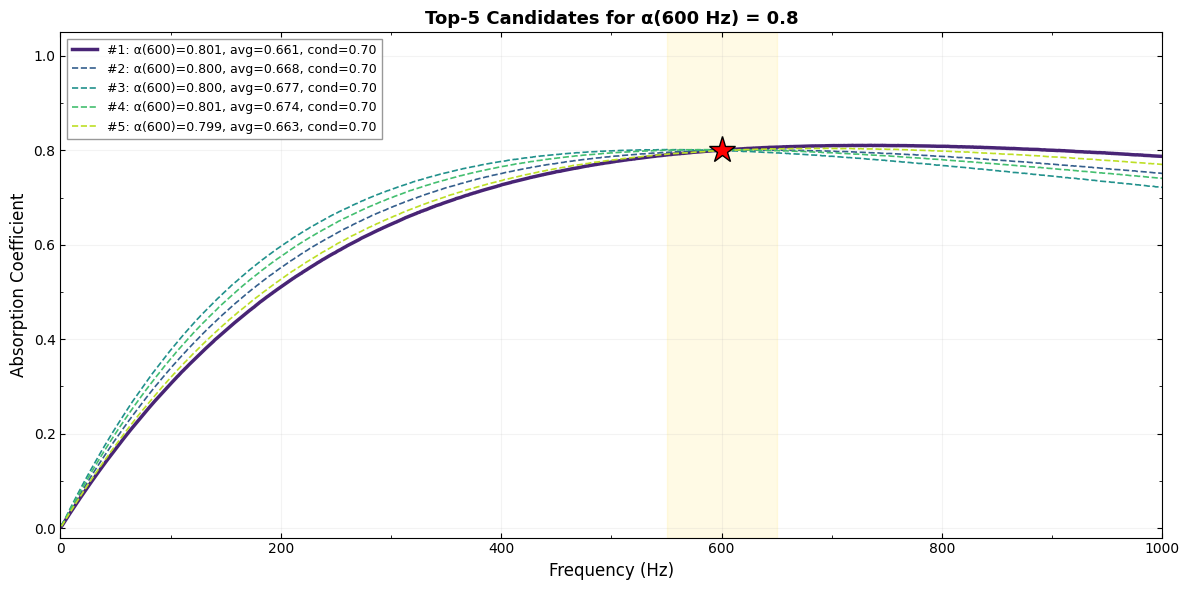


TOP-5 CANDIDATES — α(600 Hz) ≈ 0.8
Rank   Cond   α@freq     Band      Avg    Score
------------------------------------------------------------
   1    0.70    0.8006    0.7999    0.6611    0.0001
   2    0.70    0.8000    0.7994    0.6679    0.0006
   3    0.70    0.7997    0.7991    0.6773    0.0009
   4    0.70    0.8014    0.8010    0.6745    0.0010
   5    0.70    0.7994    0.7988    0.6630    0.0012

PARAMETER COMPARISON — Top 3 designs
Param               #1            #2            #3
--------------------------------------------------
  d1            8.6955       16.9949       16.2729
  d2            5.8090       17.6987       15.5623
  d3            6.8284        9.1630       20.0000
  d4           14.2850        2.8867        8.1217
  d5            1.5661       10.6801        4.7322
  d6            4.2987       15.8083        8.9709
  d7            4.0928        3.3803        4.2049
  d8           14.2312       14.0943       10.9999
  d9           19.6731        1.9432      

In [ ]:
# ==========================================
# TOP-5 CANDIDATES — spectra overlay + parameter table
# ==========================================

top_k = 5
top_indices = ranking[:top_k]

# ── Plot: overlay top-5 spectra ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))

cmap_top = plt.cm.viridis(np.linspace(0.1, 0.9, top_k))

for rank, idx in enumerate(top_indices):
    spec = spectra[idx]
    cond_lev = all_cond_levels[idx]
    alpha_at_f = spec[TARGET_FREQ - 1]
    avg_spec = spec.mean()
    lw = 2.5 if rank == 0 else 1.2
    ls = '-' if rank == 0 else '--'
    ax.plot(frequencies, spec, color=cmap_top[rank], linewidth=lw, linestyle=ls,
            label=f'#{rank+1}: α({TARGET_FREQ})={alpha_at_f:.3f}, '
                  f'avg={avg_spec:.3f}, cond={cond_lev:.2f}')

# Target marker
ax.plot(TARGET_FREQ, TARGET_ALPHA_AT_FREQ, marker='*', markersize=20,
        color='red', zorder=5, markeredgecolor='black', markeredgewidth=1.0)

ax.axvspan(max(1, TARGET_FREQ - BANDWIDTH), min(1000, TARGET_FREQ + BANDWIDTH),
           alpha=0.10, color='gold', zorder=0)

ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Absorption Coefficient', fontsize=12)
ax.set_xlim(0, 1000)
ax.set_ylim(-0.02, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=10)
ax.legend(loc='upper left', fontsize=9, frameon=True, fancybox=False, edgecolor='grey')
ax.grid(True, alpha=0.15)
ax.set_title(f'Top-{top_k} Candidates for α({TARGET_FREQ} Hz) = {TARGET_ALPHA_AT_FREQ}',
             fontsize=13, fontweight='bold')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig(f'../figures/freq_targeted_top{top_k}_{TARGET_FREQ}Hz.png',
            dpi=300, bbox_inches='tight')
plt.show()

# ── Table: top-5 parameters ─────────────────────────────────────────────────
print(f"\n{'='*100}")
print(f"TOP-{top_k} CANDIDATES — α({TARGET_FREQ} Hz) ≈ {TARGET_ALPHA_AT_FREQ}")
print(f"{'='*100}")
header = f"{'Rank':>4} {'Cond':>6} {'α@freq':>8} {'Band':>8} {'Avg':>8} {'Score':>8}"
print(header)
print("-" * 60)

for rank, idx in enumerate(top_indices):
    spec = spectra[idx]
    print(f"  {rank+1:>2}   {all_cond_levels[idx]:>5.2f}  {spec[TARGET_FREQ-1]:>8.4f}"
          f"  {alpha_in_band[idx]:>8.4f}  {spec.mean():>8.4f}  {score[idx]:>8.4f}")

# ── Full parameter comparison for top-3 ─────────────────────────────────────
print(f"\n{'='*100}")
print(f"PARAMETER COMPARISON — Top 3 designs")
print(f"{'='*100}")
print(f"{'Param':<8}", end="")
for r in range(min(3, top_k)):
    print(f"  {'#'+str(r+1):>12}", end="")
print()
print("-" * 50)

for pi, pname in enumerate(PARAM_NAMES):
    fmt = '.4f' if pname != 'E' else '.2e'
    print(f"  {pname:<6}", end="")
    for r in range(min(3, top_k)):
        val = all_candidates[top_indices[r], pi]
        print(f"  {val:>12{fmt}}", end="")
    print()

print(f"{'='*100}")

## Best Test Sample — All 20 Candidates Full Absorption Curves

**Purpose:** For the **top-1 best-performing test sample** (lowest spectral MSE), re-generate all 20 candidates and plot every candidate's **full 1–1000 Hz absorption curve** through the independent Theoretical Model (paper's exact TMM).

**What this shows:**
- 20 solid curves — one per candidate design, each computed via `Theoretical_model.py`
- 1 dashed curve — the **target absorption spectrum** (the full 1000-point conditioning input)
- Demonstrates the **diversity** of designs the cINN proposes for a single target spectrum


In [ ]:
# ==========================================
# BEST TEST SAMPLE — ALL 20 CANDIDATES FULL ABSORPTION CURVES
# ==========================================
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
from Theoretical_model import calculate_acoustic_properties, get_base_case_parameters
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import torch

# ── Step 1: Find best test sample ────────────────────────────────────────────
mse_errors = np.array(test_results['spectrum_mse'])
best_sample_idx = np.argmin(mse_errors)
target_spectrum = Y_test[best_sample_idx]
target_avg = np.mean(target_spectrum)
best_error = np.sqrt(mse_errors[best_sample_idx])

print(f"{'='*70}")
print(f"BEST TEST SAMPLE — ALL 20 CANDIDATES")
print(f"{'='*70}")
print(f"  Test sample index:  {best_sample_idx}")
print(f"  Target avg absorption: {target_avg:.6f}")
print(f"  Best-of-20 RMSE:      {best_error:.6f}")

# ── Step 2: Re-generate 20 candidates via cINN ──────────────────────────────
NUM_CANDIDATES = 20
cond = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(NUM_CANDIDATES, 1).to(device)
z_random = torch.randn(NUM_CANDIDATES, 20).to(device)

print(f"\nGenerating {NUM_CANDIDATES} candidates for target spectrum (avg={target_avg:.6f})...")
model.eval()
with torch.no_grad():
    gen_norm = model(z_random, cond, rev=True)
gen_real = scaler_params.inverse_transform(gen_norm.cpu().numpy())
gen_real = validate_and_clip_parameters(gen_real)

# ── Step 3: Compute full absorption curve for each candidate via TMM ────────
print(f"Computing full 1–1000 Hz curves via Theoretical Model (paper's TMM)...")

def params_array_to_dict_local(params_row):
    return {
        'rho': float(params_row[16]), 'eta': float(params_row[17]),
        'E':   float(params_row[18]), 'nu':  float(params_row[19]),
        'W':   2000.0,
        'd':   [float(params_row[i]) for i in range(10)],
        'm':   {2: float(params_row[10]), 3: float(params_row[11]),
                5: float(params_row[12]), 6: float(params_row[13]),
                8: float(params_row[14]), 9: float(params_row[15])},
    }

all_freqs = None
all_curves = np.zeros((NUM_CANDIDATES, 1000))
all_avgs = np.zeros(NUM_CANDIDATES)

for ci in range(NUM_CANDIDATES):
    params_dict = params_array_to_dict_local(gen_real[ci])
    freq_i, alpha_i, _, _ = calculate_acoustic_properties(params_dict)
    all_curves[ci] = alpha_i
    all_avgs[ci] = np.mean(alpha_i)
    if all_freqs is None:
        all_freqs = freq_i

# Rank by full-curve RMSE
curve_rmses = np.sqrt(np.mean((all_curves - target_spectrum) ** 2, axis=1))
ranking = np.argsort(curve_rmses)

print(f"\n  {'Cand':>4}  {'Avg Absorption':>16}  {'Curve RMSE':>12}")
print(f"  {'-'*40}")
for rank, idx in enumerate(ranking):
    marker = " <-- BEST" if rank == 0 else ""
    print(f"  {idx+1:>4}  {all_avgs[idx]:>16.6f}  {curve_rmses[idx]:>12.6f}{marker}")

# ── Step 4: Plot all 20 candidates + target spectrum ────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
cmap = plt.cm.tab20(np.linspace(0, 1, NUM_CANDIDATES))

for ci in range(NUM_CANDIDATES):
    rank_of_ci = np.where(ranking == ci)[0][0]
    lw = 2.5 if rank_of_ci == 0 else 0.9
    alpha_line = 1.0 if rank_of_ci == 0 else 0.55
    label = (f'Candidate {ci+1} (avg={all_avgs[ci]:.4f}, RMSE={curve_rmses[ci]:.4f})'
             if rank_of_ci < 3 else (f'Candidate {ci+1}' if ci == 0 else None))
    ax.plot(all_freqs, all_curves[ci], color=cmap[ci], linewidth=lw,
            alpha=alpha_line, label=label)

# Highlight best candidate
best_ci = ranking[0]
ax.plot(all_freqs, all_curves[best_ci], color='black', linewidth=2.5, linestyle='-',
        zorder=10, label=f'Best: Cand {best_ci+1} (RMSE={curve_rmses[best_ci]:.4f})')

# Target spectrum — dashed line
ax.plot(all_freqs, target_spectrum, color='red', linestyle='--', linewidth=2.5, zorder=5,
        label=f'Target spectrum (avg={target_avg:.4f})')

ax.set_xlabel('Frequency (Hz)', fontsize=13)
ax.set_ylabel('Absorption Coefficient', fontsize=13)
ax.set_xlim(0, 1000)
ax.set_ylim(-0.02, 1.05)
ax.set_yticks(np.arange(0, 1.1, 0.2))
ax.yaxis.set_minor_locator(AutoMinorLocator(2))
ax.xaxis.set_minor_locator(AutoMinorLocator(2))
ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
ax.legend(loc='upper right', fontsize=8, frameon=True, fancybox=False,
          edgecolor='grey', ncol=2)
ax.grid(True, alpha=0.15)
ax.set_title(f'Best Test Sample (idx={best_sample_idx}) — All {NUM_CANDIDATES} Candidates\n'
             f'Full 1–1000 Hz via Theoretical Model TMM | cINN Full-Spectrum',
             fontsize=13, fontweight='bold')

plt.tight_layout()
os.makedirs('../figures', exist_ok=True)
plt.savefig(f'../figures/cinn_best_sample_all{NUM_CANDIDATES}_candidates.png',
            dpi=300, bbox_inches='tight')
plt.savefig(f'../figures/cinn_best_sample_all{NUM_CANDIDATES}_candidates.pdf',
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved to ../figures/cinn_best_sample_all{NUM_CANDIDATES}_candidates.png/pdf")
plt.show()


In [ ]:
# ==========================================
# TOP-4 BEST TEST SAMPLES — TOP-5 CANDIDATES EACH (2×2 SUBPLOTS)
# ==========================================
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
from Theoretical_model import calculate_acoustic_properties
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import torch

NUM_SAMPLES = 4
NUM_CANDIDATES = 20
TOP_K = 5

mse_errors = np.array(test_results['spectrum_mse'])
sorted_sample_indices = np.argsort(mse_errors)
top_sample_indices = sorted_sample_indices[:NUM_SAMPLES]

print(f"{'='*70}")
print(f"TOP-{NUM_SAMPLES} BEST TEST SAMPLES — TOP-{TOP_K} CANDIDATES EACH")
print(f"{'='*70}")
for rank, si in enumerate(top_sample_indices):
    print(f"  #{rank+1}: sample idx={si}, RMSE={np.sqrt(mse_errors[si]):.6f}")

def params_array_to_dict_sub(params_row):
    return {
        'rho': float(params_row[16]), 'eta': float(params_row[17]),
        'E':   float(params_row[18]), 'nu':  float(params_row[19]),
        'W':   2000.0,
        'd':   [float(params_row[i]) for i in range(10)],
        'm':   {2: float(params_row[10]), 3: float(params_row[11]),
                5: float(params_row[12]), 6: float(params_row[13]),
                8: float(params_row[14]), 9: float(params_row[15])},
    }

sample_data = []
for rank, si in enumerate(top_sample_indices):
    target_spectrum = Y_test[si]
    print(f"\n  Sample #{rank+1} (idx={si}): generating {NUM_CANDIDATES} candidates...")

    cond = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(NUM_CANDIDATES, 1).to(device)
    z_random = torch.randn(NUM_CANDIDATES, 20).to(device)
    model.eval()
    with torch.no_grad():
        gen_norm = model(z_random, cond, rev=True)
    gen_real = scaler_params.inverse_transform(gen_norm.cpu().numpy())
    gen_real = validate_and_clip_parameters(gen_real)

    curves = np.zeros((NUM_CANDIDATES, 1000))
    freqs = None
    for ci in range(NUM_CANDIDATES):
        f_i, a_i, _, _ = calculate_acoustic_properties(params_array_to_dict_sub(gen_real[ci]))
        curves[ci] = a_i
        if freqs is None:
            freqs = f_i

    curve_rmses = np.sqrt(np.mean((curves - target_spectrum) ** 2, axis=1))
    ranked = np.argsort(curve_rmses)

    sample_data.append({
        'sample_idx': si, 'target': target_spectrum, 'freqs': freqs,
        'curves': curves, 'rmses': curve_rmses, 'ranked': ranked,
    })
    print(f"    Best candidate: RMSE={curve_rmses[ranked[0]]:.6f}")

fig, axes = plt.subplots(2, 2, figsize=(20, 14), sharex=True, sharey=True)
axes_flat = axes.flatten()
colours_top5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

for panel_idx, (sd, ax) in enumerate(zip(sample_data, axes_flat)):
    freqs = sd['freqs']
    ranked = sd['ranked']
    target = sd['target']

    for k in range(TOP_K):
        ci = ranked[k]
        ax.plot(freqs, sd['curves'][ci], color=colours_top5[k],
                linewidth=2.5 if k == 0 else 1.4,
                alpha=1.0 if k == 0 else 0.7,
                label=f'#{k+1} (RMSE={sd["rmses"][ci]:.4f})')

    ax.plot(freqs, target, color='red', linestyle='--', linewidth=2.0,
            label=f'Target spectrum')

    ax.set_ylim(-0.02, 1.05)
    ax.set_xlim(0, 1000)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
    ax.grid(True, alpha=0.15)
    ax.legend(loc='upper right', fontsize=10, frameon=True, fancybox=False, edgecolor='grey')
    ax.set_title(f'({chr(97+panel_idx)}) Sample idx={sd["sample_idx"]}  |  '
                 f'Avg \u03b1 = {np.mean(target):.4f}', fontsize=13, fontweight='bold')

for ax in axes[-1, :]:
    ax.set_xlabel('Frequency (Hz)', fontsize=13)
for ax in axes[:, 0]:
    ax.set_ylabel('Absorption Coefficient', fontsize=13)

fig.suptitle(f'Top-{NUM_SAMPLES} Best Test Samples — Top-{TOP_K} Candidate Absorption Curves\n'
             f'(Full 1–1000 Hz via Theoretical Model TMM | cINN)',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.96])
os.makedirs('../figures', exist_ok=True)
plt.savefig(f'../figures/cinn_top{NUM_SAMPLES}_samples_top{TOP_K}_candidates.png',
            dpi=300, bbox_inches='tight')
plt.savefig(f'../figures/cinn_top{NUM_SAMPLES}_samples_top{TOP_K}_candidates.pdf',
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved")
plt.show()


In [ ]:
# ==========================================
# TOP-6 BEST TEST SAMPLES — TOP-5 CANDIDATES EACH (3×2 SUBPLOTS)
# ==========================================
import sys, os
sys.path.insert(0, os.path.join('..', 'src'))
from Theoretical_model import calculate_acoustic_properties
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
import numpy as np
import torch

NUM_SAMPLES = 6
NUM_CANDIDATES = 20
TOP_K = 5

mse_errors = np.array(test_results['spectrum_mse'])
sorted_sample_indices = np.argsort(mse_errors)
top_sample_indices = sorted_sample_indices[:NUM_SAMPLES]

print(f"{'='*70}")
print(f"TOP-{NUM_SAMPLES} BEST TEST SAMPLES — TOP-{TOP_K} CANDIDATES EACH")
print(f"{'='*70}")

def params_array_to_dict_sub(params_row):
    return {
        'rho': float(params_row[16]), 'eta': float(params_row[17]),
        'E':   float(params_row[18]), 'nu':  float(params_row[19]),
        'W':   2000.0,
        'd':   [float(params_row[i]) for i in range(10)],
        'm':   {2: float(params_row[10]), 3: float(params_row[11]),
                5: float(params_row[12]), 6: float(params_row[13]),
                8: float(params_row[14]), 9: float(params_row[15])},
    }

sample_data = []
for rank, si in enumerate(top_sample_indices):
    target_spectrum = Y_test[si]
    print(f"  Sample #{rank+1} (idx={si}): generating...")
    cond = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(NUM_CANDIDATES, 1).to(device)
    z_random = torch.randn(NUM_CANDIDATES, 20).to(device)
    model.eval()
    with torch.no_grad():
        gen_norm = model(z_random, cond, rev=True)
    gen_real = scaler_params.inverse_transform(gen_norm.cpu().numpy())
    gen_real = validate_and_clip_parameters(gen_real)

    curves = np.zeros((NUM_CANDIDATES, 1000))
    freqs = None
    for ci in range(NUM_CANDIDATES):
        f_i, a_i, _, _ = calculate_acoustic_properties(params_array_to_dict_sub(gen_real[ci]))
        curves[ci] = a_i
        if freqs is None: freqs = f_i

    curve_rmses = np.sqrt(np.mean((curves - target_spectrum) ** 2, axis=1))
    ranked = np.argsort(curve_rmses)
    sample_data.append({
        'sample_idx': si, 'target': target_spectrum, 'freqs': freqs,
        'curves': curves, 'rmses': curve_rmses, 'ranked': ranked,
    })
    print(f"    Best RMSE={curve_rmses[ranked[0]]:.6f}")

fig, axes = plt.subplots(2, 3, figsize=(24, 10), sharex=True, sharey=True)
axes_flat = axes.flatten()
colours_top5 = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b']

for panel_idx, (sd, ax) in enumerate(zip(sample_data, axes_flat)):
    for k in range(TOP_K):
        ci = sd['ranked'][k]
        ax.plot(sd['freqs'], sd['curves'][ci], color=colours_top5[k],
                linewidth=1.8 if k == 0 else 1.0, alpha=1.0 if k == 0 else 0.7,
                label=f'#{k+1} (RMSE={sd["rmses"][ci]:.4f})')
    ax.plot(sd['freqs'], sd['target'], color='red', linestyle='--', linewidth=2.0,
            label='Target spectrum')
    ax.set_ylim(-0.02, 1.05); ax.set_xlim(0, 1000)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=9)
    ax.grid(True, alpha=0.15)
    ax.legend(loc='upper right', fontsize=7, frameon=True, fancybox=False, edgecolor='grey')
    ax.set_title(f'({chr(97+panel_idx)}) idx={sd["sample_idx"]}  |  '
                 f'Avg \u03b1 = {np.mean(sd["target"]):.4f}', fontsize=11, fontweight='bold')

for ax in axes[-1, :]: ax.set_xlabel('Frequency (Hz)', fontsize=12)
for ax in axes[:, 0]: ax.set_ylabel('Absorption Coefficient', fontsize=12)

fig.suptitle(f'Top-{NUM_SAMPLES} Best Test Samples — Top-{TOP_K} Candidates (cINN)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(rect=[0, 0, 1, 0.96])
os.makedirs('../figures', exist_ok=True)
plt.savefig(f'../figures/cinn_top{NUM_SAMPLES}_samples_top{TOP_K}_candidates.png',
            dpi=300, bbox_inches='tight')
plt.savefig(f'../figures/cinn_top{NUM_SAMPLES}_samples_top{TOP_K}_candidates.pdf',
            dpi=300, bbox_inches='tight')
print(f"\nFigure saved")
plt.show()


## Full Design-Space Sweep — Target Absorption 0.1 → 1.0

**Pipeline (GPU-accelerated, gated by `RUN_SWEEP` toggle):**
1. Sweep target avg absorption from **1.0 → 0.1** in steps of 0.001 (901 targets)
2. For each target: find closest test spectrum, generate **20 candidates** via cINN, compute full spectra via **GPU TMM**, pick **best-of-20**
3. Plot **two figures**:
   - **(a) Absorption curves** — all 901 best curves overlaid, colored by target level
   - **(b) Heatmap** — frequency (x) vs target absorption (y), color = absorption coefficient


In [ ]:
# ==========================================
# FULL DESIGN-SPACE SWEEP — GPU ACCELERATED (cINN)
# Target absorption: 1.0, 0.999, 0.998, ... 0.1
# ==========================================
import time, os
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import Normalize
from matplotlib import cm

if not RUN_SWEEP:
    print("SWEEP SKIPPED (set RUN_SWEEP = True to enable)")
else:
    NUM_CAND = 20
    TMM_CHUNK = 2000

    # ── Step 1: Create target sweep ─────────────────────────────────────────
    target_values = np.round(np.arange(1.0, 0.1 - 1e-9, -0.001), 3)
    N_targets = len(target_values)
    print(f"{'='*70}")
    print(f"DESIGN-SPACE SWEEP  |  {N_targets} targets  |  {NUM_CAND} candidates each")
    print(f"  Range: {target_values[0]:.3f} → {target_values[-1]:.3f}")
    print(f"{'='*70}")

    # ── Step 2: For each target level, find closest test spectrum ────────────
    y_test_avgs = np.mean(Y_test, axis=1)
    t0 = time.time()

    all_gen_real = []
    for tgt in target_values:
        closest_idx = np.argmin(np.abs(y_test_avgs - tgt))
        target_spectrum = Y_test[closest_idx]

        cond = torch.FloatTensor(target_spectrum).unsqueeze(0).repeat(NUM_CAND, 1).to(device)
        z_random = torch.randn(NUM_CAND, 20).to(device)
        model.eval()
        with torch.no_grad():
            gen_norm = model(z_random, cond, rev=True)
        gen_real = scaler_params.inverse_transform(gen_norm.cpu().numpy())
        gen_real = validate_and_clip_parameters(gen_real)
        all_gen_real.append(gen_real)

    all_gen_real = np.concatenate(all_gen_real, axis=0)  # (N_targets*20, 20)
    t_sample = time.time() - t0
    print(f"  Sampling done: {t_sample:.1f}s ({len(all_gen_real):,} candidates)")

    # ── Step 3: Full-spectrum TMM on GPU ────────────────────────────────────
    print(f"\nComputing full spectra via GPU TMM...")
    t1 = time.time()
    all_spectra = calculate_absorption_tmm_batch_spectrum(all_gen_real, chunk_size=TMM_CHUNK)
    t_tmm = time.time() - t1
    print(f"  GPU TMM done: {t_tmm:.1f}s  |  shape: {all_spectra.shape}")

    # ── Step 4: Best-of-20 selection ────────────────────────────────────────
    all_spectra_r = all_spectra.reshape(N_targets, NUM_CAND, 1000)
    all_avgs = all_spectra_r.mean(axis=2)
    targets_col = target_values.reshape(-1, 1)
    errors = np.abs(all_avgs - targets_col) / (targets_col + 1e-8) * 100
    best_indices = np.argmin(errors, axis=1)

    best_spectra = np.zeros((N_targets, 1000))
    best_avgs = np.zeros(N_targets)
    best_errors = np.zeros(N_targets)
    for i in range(N_targets):
        bi = best_indices[i]
        best_spectra[i] = all_spectra_r[i, bi]
        best_avgs[i] = all_avgs[i, bi]
        best_errors[i] = errors[i, bi]

    # Keep gen_real for Pareto/t-SNE (reshaped)
    all_gen_real_r = all_gen_real.reshape(N_targets, NUM_CAND, 20)
    sweep_params = np.zeros((N_targets, 20))
    for i in range(N_targets):
        sweep_params[i] = all_gen_real_r[i, best_indices[i]]

    t_total = time.time() - t0
    print(f"\n  Total time: {t_total:.1f}s")
    print(f"  Mean error: {np.mean(best_errors):.3f}%")
    print(f"  Median error: {np.median(best_errors):.3f}%")

    frequencies = np.arange(1, 1001, 1)

    # ═══ FIGURE (a): ALL CURVES ═══════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(14, 8))
    norm_c = Normalize(vmin=target_values.min(), vmax=target_values.max())
    cmap_c = cm.viridis
    for i in range(N_targets):
        color = cmap_c(norm_c(target_values[i]))
        ax.plot(frequencies, best_spectra[i], color=color, linewidth=0.4, alpha=0.6)
    sm = cm.ScalarMappable(cmap=cmap_c, norm=norm_c)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label('Target Avg Absorption', fontsize=12)
    ax.set_xlabel('Frequency (Hz)', fontsize=13)
    ax.set_ylabel('Absorption Coefficient', fontsize=13)
    ax.set_xlim(0, 1000); ax.set_ylim(-0.02, 1.05)
    ax.set_yticks(np.arange(0, 1.1, 0.2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
    ax.grid(True, alpha=0.15)
    ax.set_title(f'Design-Space Sweep: {N_targets} Targets (0.1 → 1.0)\n'
                 f'Best-of-{NUM_CAND} — Full Absorption Curves via GPU TMM (cINN)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/cinn_sweep_all_curves.png', dpi=300, bbox_inches='tight')
    plt.savefig('../figures/cinn_sweep_all_curves.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # ═══ FIGURE (b): HEATMAP ══════════════════════════════════════════════════
    fig, ax = plt.subplots(figsize=(14, 8))
    heatmap_data = best_spectra[::-1] if target_values[0] > target_values[-1] else best_spectra
    y_min, y_max = float(np.min(target_values)), float(np.max(target_values))
    im = ax.imshow(heatmap_data, aspect='auto', origin='lower',
                   extent=[1, 1000, y_min, y_max], cmap='inferno', vmin=0, vmax=1,
                   interpolation='bilinear')
    cbar = plt.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label('Absorption Coefficient', fontsize=12)
    ax.set_xlabel('Frequency (Hz)', fontsize=13)
    ax.set_ylabel('Target Avg Absorption', fontsize=13)
    ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
    ax.set_title(f'Design-Space Heatmap: {N_targets} Targets × 1000 Frequencies (cINN)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('../figures/cinn_sweep_heatmap.png', dpi=300, bbox_inches='tight')
    plt.savefig('../figures/cinn_sweep_heatmap.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print(f"Sweep figures saved to ../figures/cinn_sweep_*.png/pdf")


## Sweep Analysis — Comprehensive Metrics Table & CSV Export

Build a detailed per-target metrics table from the 901-sample sweep and export to CSV.  
Columns include absolute / relative / squared errors, spectrum statistics (std, min, max, peak freq),  
bandwidth coverage, bias direction, and more — designed for pattern discovery.

In [ ]:
# ============================================================
# COMPREHENSIVE SWEEP METRICS TABLE + CSV EXPORT
# ============================================================
if not RUN_SWEEP or 'best_spectra' not in globals():
    print("SKIPPED: Run sweep cell first (RUN_SWEEP=True)")
else:
    import pandas as pd

    achieved_avg   = best_avgs
    abs_error      = np.abs(target_values - achieved_avg)
    signed_error   = achieved_avg - target_values
    rel_error      = abs_error / (target_values + 1e-12)
    pct_rel_error  = rel_error * 100
    squared_error  = (target_values - achieved_avg) ** 2

    spec_min  = best_spectra.min(axis=1)
    spec_max  = best_spectra.max(axis=1)
    spec_std  = best_spectra.std(axis=1)
    peak_freq = np.argmax(best_spectra, axis=1) + 1
    best_cand = best_indices + 1

    df = pd.DataFrame({
        'target_avg_absorption':   np.round(target_values, 4),
        'achieved_avg_absorption': np.round(achieved_avg, 6),
        'absolute_error':          np.round(abs_error, 6),
        'pct_relative_error':      np.round(pct_rel_error, 4),
        'spec_min':                np.round(spec_min, 6),
        'spec_max':                np.round(spec_max, 6),
        'spec_std':                np.round(spec_std, 6),
        'peak_frequency_Hz':       peak_freq,
        'best_candidate_idx':      best_cand,
    })

    csv_path = '../data/cinn_sweep_901_metrics.csv'
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)
    df.to_csv(csv_path, index=False)
    print(f"CSV saved → {csv_path}  ({len(df)} rows × {len(df.columns)} cols)")

    print(f"\n{'='*70}")
    print(f"SUMMARY STATISTICS ACROSS {len(df)} TARGETS")
    print(f"{'='*70}")
    print(f"  Mean Abs Error:        {abs_error.mean():.6f}")
    print(f"  Mean % Rel Error:      {pct_rel_error.mean():.4f}%")
    print(f"  Median % Rel Error:    {np.median(pct_rel_error):.4f}%")
    print(f"  P95 % Rel Error:       {np.percentile(pct_rel_error, 95):.4f}%")
    print(f"  RMSE:                  {np.sqrt(squared_error.mean()):.6f}")
    from sklearn.metrics import r2_score
    print(f"  R²:                    {r2_score(target_values, achieved_avg):.6f}")
    print(f"{'='*70}")


## Pareto Front & t-SNE / UMAP — Design-Space Structure Analysis

**Gated by `RUN_MANIFOLD` toggle.** Two publication-quality figures from the 901-target sweep:

1. **Pareto Front** — Total coating thickness vs achieved average absorption
2. **t-SNE / UMAP** of the 20-dimensional design parameters — colored by target absorption level


In [ ]:
# ============================================================
# PARETO FRONT + t-SNE / UMAP (uses sweep_params from sweep cell)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib import cm
from matplotlib.ticker import AutoMinorLocator
from sklearn.manifold import TSNE

if not RUN_MANIFOLD:
    print("MANIFOLD ANALYSIS SKIPPED (set RUN_MANIFOLD = True to enable)")
elif 'sweep_params' not in globals():
    print("ERROR: sweep_params not found. Run the sweep cell first (RUN_SWEEP=True).")
else:
    print(f"Analyzing {len(sweep_params)} sweep designs...")

    total_thickness = sweep_params[:, :10].sum(axis=1)
    avg_hollow = sweep_params[:, 10:16].mean(axis=1)

    # ═══ PARETO FRONT ═══════════════════════════════════════════════════════
    fig, axes = plt.subplots(1, 2, figsize=(18, 7.5))
    norm_p = Normalize(vmin=target_values.min(), vmax=target_values.max())

    ax = axes[0]
    sc = ax.scatter(total_thickness, best_avgs, c=target_values, cmap='viridis',
                    s=18, alpha=0.75, edgecolors='none', norm=norm_p)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label('Target Avg Absorption', fontsize=12)
    z = np.polyfit(total_thickness, best_avgs, 2)
    x_fit = np.linspace(total_thickness.min(), total_thickness.max(), 200)
    ax.plot(x_fit, np.polyval(z, x_fit), 'r--', linewidth=2, alpha=0.7, label='Quadratic trend')
    ax.set_xlabel('Total Coating Thickness $\\sum d_i$ (mm)', fontsize=13)
    ax.set_ylabel('Achieved Avg Absorption', fontsize=13)
    ax.set_ylim(-0.02, 1.05)
    ax.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
    ax.grid(True, alpha=0.15); ax.legend(fontsize=11, loc='lower right')
    ax.set_title('(a) Pareto Front: Thickness vs Absorption (cINN)', fontsize=14, fontweight='bold')
    corr = np.corrcoef(total_thickness, best_avgs)[0, 1]
    ax.text(0.03, 0.97, f'Pearson r = {corr:+.3f}\nN = {len(sweep_params)}',
            transform=ax.transAxes, fontsize=10, va='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.85))

    ax2 = axes[1]
    sc2 = ax2.scatter(avg_hollow, best_avgs, c=target_values, cmap='viridis',
                      s=18, alpha=0.75, edgecolors='none', norm=norm_p)
    cbar2 = plt.colorbar(sc2, ax=ax2, shrink=0.85, pad=0.02)
    cbar2.set_label('Target Avg Absorption', fontsize=12)
    z2 = np.polyfit(avg_hollow, best_avgs, 2)
    x_fit2 = np.linspace(avg_hollow.min(), avg_hollow.max(), 200)
    ax2.plot(x_fit2, np.polyval(z2, x_fit2), 'r--', linewidth=2, alpha=0.7, label='Quadratic trend')
    ax2.set_xlabel('Mean Hollow Diameter $\\bar{m}$ (mm)', fontsize=13)
    ax2.set_ylabel('Achieved Avg Absorption', fontsize=13)
    ax2.set_ylim(-0.02, 1.05)
    ax2.xaxis.set_minor_locator(AutoMinorLocator(2))
    ax2.yaxis.set_minor_locator(AutoMinorLocator(2))
    ax2.tick_params(direction='in', which='both', top=True, right=True, labelsize=11)
    ax2.grid(True, alpha=0.15); ax2.legend(fontsize=11, loc='lower right')
    ax2.set_title('(b) Hollow Diameter vs Absorption (cINN)', fontsize=14, fontweight='bold')

    plt.suptitle('Design-Space Analysis — cINN Full-Spectrum Inverse Design',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    os.makedirs('../figures', exist_ok=True)
    plt.savefig('../figures/cinn_pareto_front.png', dpi=300, bbox_inches='tight')
    plt.savefig('../figures/cinn_pareto_front.pdf', dpi=300, bbox_inches='tight')
    plt.show()

    # ═══ t-SNE ══════════════════════════════════════════════════════════════
    print("\nComputing t-SNE embedding (this may take ~30s)...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
    emb_tsne = tsne.fit_transform(sweep_params)

    has_umap = False
    try:
        import umap
        print("Computing UMAP embedding...")
        reducer = umap.UMAP(n_components=2, random_state=42)
        emb_umap = reducer.fit_transform(sweep_params)
        has_umap = True
    except ImportError:
        print("UMAP not installed — skipping UMAP panel")

    norm_t = Normalize(vmin=target_values.min(), vmax=target_values.max())
    ncols = 2 if has_umap else 1
    fig, axes_t = plt.subplots(1, ncols, figsize=(9 * ncols, 8))
    if ncols == 1: axes_t = [axes_t]

    ax = axes_t[0]
    sc = ax.scatter(emb_tsne[:, 0], emb_tsne[:, 1], c=target_values, cmap='viridis',
                    s=28, alpha=0.85, edgecolors='none', norm=norm_t)
    cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label('Target Avg Absorption', fontsize=12)
    ax.set_xlabel('t-SNE 1', fontsize=13); ax.set_ylabel('t-SNE 2', fontsize=13)
    ax.tick_params(direction='in', which='both', top=True, right=True)
    ax.set_title('(a) t-SNE of 20D Design Parameters (cINN)', fontsize=14, fontweight='bold')
    ax.grid(True, alpha=0.12)

    if has_umap:
        ax2 = axes_t[1]
        sc2 = ax2.scatter(emb_umap[:, 0], emb_umap[:, 1], c=target_values, cmap='viridis',
                          s=28, alpha=0.85, edgecolors='none', norm=norm_t)
        cbar2 = plt.colorbar(sc2, ax=ax2, shrink=0.85, pad=0.02)
        cbar2.set_label('Target Avg Absorption', fontsize=12)
        ax2.set_xlabel('UMAP 1', fontsize=13); ax2.set_ylabel('UMAP 2', fontsize=13)
        ax2.tick_params(direction='in', which='both', top=True, right=True)
        ax2.set_title('(b) UMAP of 20D Design Parameters (cINN)', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.12)

    plt.tight_layout()
    plt.savefig('../figures/cinn_tsne_umap_design_space.png', dpi=300, bbox_inches='tight')
    plt.savefig('../figures/cinn_tsne_umap_design_space.pdf', dpi=300, bbox_inches='tight')
    plt.show()
    print("Saved: ../figures/cinn_tsne_umap_design_space.png/pdf")


In [ ]:
# ============================================================
# TNR + HIGH-QUALITY RE-RENDER: t-SNE / UMAP DESIGN SPACE
# Uses existing variables from the previous analysis cell.
# ============================================================
import os
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

plot_rc = {
    'font.family': 'serif',
    'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset': 'stix',
    'axes.titleweight': 'bold',
    'axes.labelsize': 18,
    'axes.titlesize': 20,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 12,
}

if 'emb_tsne' not in globals():
    raise RuntimeError('emb_tsne not found. Run the t-SNE generation cell first.')

use_umap = bool(globals().get('has_umap', False) and ('emb_umap' in globals()))
ncols = 2 if use_umap else 1
norm_t = Normalize(vmin=target_values.min(), vmax=target_values.max())

os.makedirs('../figures', exist_ok=True)

with plt.rc_context(plot_rc):
    fig, axes = plt.subplots(1, ncols, figsize=(9 * ncols, 8))
    if ncols == 1:
        axes = [axes]

    # ---- t-SNE panel ----
    ax = axes[0]
    sc = ax.scatter(
        emb_tsne[:, 0], emb_tsne[:, 1],
        c=target_values, cmap='viridis', s=28, alpha=0.85,
        edgecolors='none', norm=norm_t
    )
    cbar = plt.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cbar.set_label('Target Avg Absorption')
    cbar.ax.tick_params(labelsize=12)

    ax.set_xlabel('t-SNE 1')
    ax.set_ylabel('t-SNE 2')
    ax.tick_params(direction='in', which='both', top=True, right=True)
    ax.set_title('t-SNE of 20D Design Parameters')
    ax.grid(True, alpha=0.12)

    # ---- UMAP panel (if available) ----
    if use_umap:
        ax2 = axes[1]
        sc2 = ax2.scatter(
            emb_umap[:, 0], emb_umap[:, 1],
            c=target_values, cmap='viridis', s=28, alpha=0.85,
            edgecolors='none', norm=norm_t
        )
        cbar2 = plt.colorbar(sc2, ax=ax2, shrink=0.85, pad=0.02)
        cbar2.set_label('Target Avg Absorption')
        cbar2.ax.tick_params(labelsize=12)

        ax2.set_xlabel('UMAP 1')
        ax2.set_ylabel('UMAP 2')
        ax2.tick_params(direction='in', which='both', top=True, right=True)
        ax2.set_title('(b) UMAP of 20D Design Parameters\n'
                      f'{N_targets} best-of-{NUM_CAND} designs, colored by target alpha')
        ax2.grid(True, alpha=0.12)

    plt.tight_layout()
    plt.savefig('../figures/cinn_tsne_umap_design_space_TNR.png', dpi=600, bbox_inches='tight', facecolor='white')
    plt.savefig('../figures/cinn_tsne_umap_design_space_TNR.pdf', bbox_inches='tight', facecolor='white')
    plt.show()

print('Saved: ../figures/cinn_tsne_umap_design_space_TNR.png/pdf')

## Publication Figure: Full Sweep Curves with Heatmap Inset (Times New Roman)

Single high-impact figure for abstract layout constraints:
- Main panel: full 901-target sweep curves (spaghetti plot)
- Top-left inset: sweep heatmap in sparse region
- One main colorbar only (target level)
- High-resolution export for publication


In [ ]:
# ============================================================
# SPAGHETTI + HEATMAP INSET (Times New Roman, publication quality)
# ============================================================
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from matplotlib.ticker import AutoMinorLocator

if not RUN_SWEEP or 'best_spectra' not in globals():
    print("SKIPPED: Run sweep cell first (RUN_SWEEP=True)")
else:
    if 'frequencies' not in globals() or len(frequencies) != best_spectra.shape[1]:
        frequencies = np.arange(1, best_spectra.shape[1] + 1)

    plot_rc = {
        'font.family': 'serif',
        'font.serif': ['Times New Roman', 'Times', 'DejaVu Serif'],
        'mathtext.fontset': 'stix',
        'axes.titleweight': 'bold',
        'axes.labelsize': 18, 'axes.titlesize': 20,
        'xtick.labelsize': 14, 'ytick.labelsize': 14,
        'legend.fontsize': 12,
    }

    with plt.rc_context(plot_rc):
        fig, ax = plt.subplots(figsize=(16, 10))
        norm_target = Normalize(vmin=target_values.min(), vmax=target_values.max())
        cmap_target = cm.viridis
        for i in range(len(target_values)):
            ax.plot(frequencies, best_spectra[i],
                    color=cmap_target(norm_target(target_values[i])),
                    linewidth=0.45, alpha=0.55)
        sm = cm.ScalarMappable(norm=norm_target, cmap=cmap_target)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.03, pad=0.025)
        cbar.set_label('Target Avg Absorption', fontsize=16)
        cbar.ax.tick_params(labelsize=13)
        ax.set_xlabel('Frequency (Hz)')
        ax.set_ylabel('Absorption Coefficient')
        ax.set_xlim(1, 1000); ax.set_ylim(-0.02, 1.05)
        ax.yaxis.set_minor_locator(AutoMinorLocator(2))
        ax.xaxis.set_minor_locator(AutoMinorLocator(2))
        ax.tick_params(direction='in', which='both', top=True, right=True)
        ax.grid(True, alpha=0.16)
        ax.set_title('Design-Space Sweep with Heatmap Inset\n901 targets, Best-of-20 GPU TMM (cINN)')

        # Inset heatmap
        heatmap_data = best_spectra[::-1] if target_values[0] > target_values[-1] else best_spectra
        y_min, y_max = float(np.min(target_values)), float(np.max(target_values))
        axins = ax.inset_axes([0.055, 0.57, 0.41, 0.37])
        axins.imshow(heatmap_data, aspect='auto', origin='lower',
                     extent=[1, 1000, y_min, y_max], cmap='inferno',
                     vmin=0, vmax=1, interpolation='bilinear')
        axins.set_title('Sweep Heatmap (Inset)', fontsize=12, pad=3)
        axins.set_xlabel('f (Hz)', fontsize=10)
        axins.set_ylabel('Target', fontsize=10)
        axins.tick_params(axis='both', labelsize=9, direction='in')
        axins.set_xticks([1, 250, 500, 750, 1000])
        axins.set_yticks([0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
        for spine in axins.spines.values():
            spine.set_linewidth(0.9); spine.set_color('black')
        axins.text(0.98, 0.02, 'Color = \u03b1',
                   transform=axins.transAxes, ha='right', va='bottom', fontsize=9,
                   bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, edgecolor='none'))

        plt.tight_layout()
        os.makedirs('../figures', exist_ok=True)
        plt.savefig('../figures/cinn_sweep_spaghetti_heatmap_inset_TNR.png',
                    dpi=600, bbox_inches='tight', facecolor='white')
        plt.savefig('../figures/cinn_sweep_spaghetti_heatmap_inset_TNR.pdf',
                    bbox_inches='tight', facecolor='white')
        print(f"Saved: ../figures/cinn_sweep_spaghetti_heatmap_inset_TNR.png/pdf")
        plt.show()
